# Multi-Resistance Antibiotic Susceptibility

## Fase 0 – Preparación y perfilado

In [96]:
# %% [markdown]
# ## Fase 0 – Preparación y perfilado del dataset

# %%
import pandas as pd
import numpy as np

# Opciones de visualización
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [97]:
# %%
DATA_PATH = "Bacteria_dataset_Multiresictance.csv"

df = pd.read_csv(DATA_PATH)

df.shape, df.columns.tolist()

((10710, 27),
 ['ID',
  'Name',
  'Email',
  'Address',
  'age/gender',
  'Souches',
  'Diabetes',
  'Hypertension',
  'Hospital_before',
  'Infection_Freq',
  'AMX/AMP',
  'AMC',
  'CZ',
  'FOX',
  'CTX/CRO',
  'IPM',
  'GEN',
  'AN',
  'Acide nalidixique',
  'ofx',
  'CIP',
  'C',
  'Co-trimoxazole',
  'Furanes',
  'colistine',
  'Collection_Date',
  'Notes'])

In [98]:
df

,ID,Name,Email,Address,age/gender,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,AMX/AMP,AMC,CZ,FOX,CTX/CRO,IPM,GEN,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,Collection_Date,Notes
0,S290,Elizabeth Lawrence,elizabeth.lawrence@example.com,"6350 Robinson Loaf Apt. 447, Paulfurt, RI 30252",37/F,S290 Escherichia coli,No,No,No,0.0,R,R,R,R,R,R,S,S,S,S,S,R,S,S,S,5 Fev 2025,Patient had fever??
1,S291,Tina Sanders,tina.sanders@example.com,"78594 Galloway Port Suite 762, South Tanyatown...",29/F,S291 Morganella morganii,True,No,No,3.0,S,R,S,R,S,R,S,S,S,S,S,S,S,S,S,08/05/2021,تم العلاج
2,S292,Erin Cooke,erin.cooke@example.com,"76661 Isaiah Manors, North Benjamin, HI 85195",77/F,S292 Proteus mirabilis,True,No,No,3.0,S,R,S,R,S,S,S,S,S,S,R,R,S,S,S,01/05/2022,NADA
3,S293,Mrs. Sharon Watson,mrs..sharon.watson@example.com,"1670 Thompson Way Apt. 520, Andrewbury, IL 11534",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-05,PACIENTO ENFERMO
4,S294,Erika Stewart,erika.stewart@example.com,"76838 Patrick Green Suite 538, Torresmouth, ME...",13/F,S294 Escherichia coli,No,Yes,No,1.0,S,S,R,R,R,R,R,R,S,S,S,S,S,S,S,error,NADA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10705,S10995,Mrs. Chelsea Brown MD,mrs..chelsea.brown.md@example.com,"23574 Palmer Lodge, South Aliciaton, GU 00728",17/M,S7382 Enterobacteria spp.,No,No,No,3.0,S,R,R,S,S,R,S,S,S,S,S,S,S,S,S,2024-12-31,see file
10706,S10996,Mary Kelley,mary.kelley@example.com,"8194 Gonzalez Hill, Loveview, SD 31189",20/F,S1479 Proeus mirabilis,True,No,Yes,3.0,S,R,S,S,S,S,S,S,S,S,S,S,S,S,S,5 Fev 2025,Patient had fever??
10707,S10997,Alexandra Smith,alexandra.smith@example.com,"213 Yates Station, Port Meganstad, PW 17799",33/M,S2983 Escherichia coli,No,No,No,0.0,R,R,S,R,R,R,S,S,S,R,S,R,S,S,S,08/05/2021,Patient had fever??
10708,S10998,April Cox,april.cox@example.com,"985 Julia Freeway Apt. 753, Dianamouth, SD 07610",86/F,S10079 Escherichia coli,No,No,No,2.0,Intermediate,s,r,i,r,Intermediate,r,s,i,r,r,s,Intermediate,r,s,05/03/2022,see file


In [99]:
# %%
# Definir grupos lógicos de columnas (según el reporte y la metadata)

ID_COL = "ID"

PII_COLS = ["Name", "Email", "Address", "Notes"]  # se eliminarán más adelante

DEMOGRAPHIC_COLS = ["age/gender", "Souches"]

RISK_FACTOR_COLS = ["Diabetes", "Hypertension", "Hospital_before", "Infection_Freq"]

ANTIBIOTIC_COLS = [
    "AMX/AMP",
    "AMC",
    "CZ",
    "FOX",
    "CTX/CRO",
    "IPM",
    "GEN",
    "AN",
    "Acide nalidixique",
    "ofx",
    "CIP",
    "C",
    "Co-trimoxazole",
    "Furanes",
    "colistine",
]

META_COLS = ["Collection_Date"]

ALL_EXPECTED_COLS = (
    [ID_COL]
    + PII_COLS
    + DEMOGRAPHIC_COLS
    + RISK_FACTOR_COLS
    + ANTIBIOTIC_COLS
    + META_COLS
)

# Comprobemos que todo está en el DataFrame
missing_cols = [c for c in ALL_EXPECTED_COLS if c not in df.columns]
extra_cols = [c for c in df.columns if c not in ALL_EXPECTED_COLS]

missing_cols, extra_cols

([], [])

In [100]:
# %%
# Info básica de tipos, memoria y primeras filas
print("Shape:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

mem_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"\nUso aproximado de memoria: {mem_mb:.2f} MB")

Shape: (10710, 27)

Tipos de datos:
ID                   object
Name                 object
Email                object
Address              object
age/gender           object
Souches              object
Diabetes             object
Hypertension         object
Hospital_before      object
Infection_Freq       object
AMX/AMP              object
AMC                  object
CZ                   object
FOX                  object
CTX/CRO              object
IPM                  object
GEN                  object
AN                   object
Acide nalidixique    object
ofx                  object
CIP                  object
C                    object
Co-trimoxazole       object
Furanes              object
colistine            object
Collection_Date      object
Notes                object
dtype: object

Uso aproximado de memoria: 14.94 MB


In [101]:
# %%
def build_column_profile(data: pd.DataFrame, sample_size: int = 5) -> pd.DataFrame:
    """
    Construye un perfil inicial por columna:
    - dtype
    - n_distinct
    - n_missing
    - pct_missing
    - ejemplos de valores no nulos
    """
    records = []
    n_rows = len(data)

    for col in data.columns:
        series = data[col]
        n_missing = series.isna().sum()
        pct_missing = (n_missing / n_rows) * 100 if n_rows > 0 else np.nan
        n_distinct = series.nunique(dropna=True)

        sample_values = series.dropna().astype(str).unique()[:sample_size].tolist()

        records.append(
            {
                "columna": col,
                "dtype": str(series.dtype),
                "n_distinct": int(n_distinct),
                "n_missing": int(n_missing),
                "pct_missing": round(pct_missing, 2),
                "ejemplos": sample_values,
            }
        )

    profile_df = pd.DataFrame(records).sort_values("columna")
    return profile_df


column_profile = build_column_profile(df)
column_profile

,columna,dtype,n_distinct,n_missing,pct_missing,ejemplos
11,AMC,object,8,632,5.90,"[R, S, s, r, Intermediate]"
10,AMX/AMP,object,8,658,6.14,"[R, S, s, i, ?]"
17,AN,object,8,628,5.86,"[S, R, i, missing, s]"
18,Acide nalidixique,object,8,622,5.81,"[S, R, Intermediate, s, r]"
3,Address,object,10710,0,0.00,"[6350 Robinson Loaf Apt. 447, Paulfurt, RI 302..."
21,C,object,8,629,5.87,"[R, S, Intermediate, i, ?]"
20,CIP,object,8,633,5.91,"[S, R, s, Intermediate, i]"
14,CTX/CRO,object,8,624,5.83,"[R, S, r, i, ?]"
12,CZ,object,8,628,5.86,"[R, S, r, Intermediate, ?]"
22,Co-trimoxazole,object,8,640,5.98,"[S, R, Intermediate, s, r]"


In [102]:
# Si quieres ver solo algunas columnas (por ejemplo, factores de riesgo + antibióticos):
# %%
column_profile[column_profile["columna"].isin(RISK_FACTOR_COLS + ANTIBIOTIC_COLS)]

,columna,dtype,n_distinct,n_missing,pct_missing,ejemplos
11,AMC,object,8,632,5.90,"[R, S, s, r, Intermediate]"
10,AMX/AMP,object,8,658,6.14,"[R, S, s, i, ?]"
17,AN,object,8,628,5.86,"[S, R, i, missing, s]"
18,Acide nalidixique,object,8,622,5.81,"[S, R, Intermediate, s, r]"
21,C,object,8,629,5.87,"[R, S, Intermediate, i, ?]"
20,CIP,object,8,633,5.91,"[S, R, s, Intermediate, i]"
14,CTX/CRO,object,8,624,5.83,"[R, S, r, i, ?]"
12,CZ,object,8,628,5.86,"[R, S, r, Intermediate, ?]"
22,Co-trimoxazole,object,8,640,5.98,"[S, R, Intermediate, s, r]"
6,Diabetes,object,4,635,5.93,"[No, True, ?, missing]"


In [103]:
# Porcentaje de valores faltantes por columna
# %%
missing_summary = (
    df.isna()
    .mean()
    .mul(100)
    .round(2)
    .rename("pct_missing")
    .to_frame()
    .sort_values("pct_missing", ascending=False)
)

missing_summary

,pct_missing
Collection_Date,6.25
AMX/AMP,6.14
GEN,6.00
Souches,5.98
Co-trimoxazole,5.98
Infection_Freq,5.97
Hospital_before,5.95
Furanes,5.95
colistine,5.94
Diabetes,5.93


In [104]:
# %%
# Duplicados por ID
n_ids = df[ID_COL].nunique(dropna=True)
n_rows = len(df)
n_dup_ids = n_rows - n_ids

print(f"Número de filas: {n_rows}")
print(f"Número de IDs únicos ({ID_COL}): {n_ids}")
print(f"Filas con ID duplicado (potencialmente problemáticas): {n_dup_ids}")

# Duplicados de fila completa
n_dup_rows = df.duplicated().sum()
print(f"Filas completamente duplicadas: {n_dup_rows}")

Número de filas: 10710
Número de IDs únicos (ID): 10710
Filas con ID duplicado (potencialmente problemáticas): 0
Filas completamente duplicadas: 0


In [105]:
# 💊 7. Exploración de codificaciones S/I/R por antibiótico
# Aquí solo miramos los valores distintos y su frecuencia relativa, para ver el desorden que luego normalizaremos.
# %%
def value_counts_normalized(series: pd.Series, max_categories: int = 15) -> pd.DataFrame:
    """Devuelve una tabla con conteos y porcentaje relativo."""
    vc = (
        series.astype("string")
              .str.strip()
              .str.lower()
              .value_counts(dropna=False)
    )

    total = vc.sum()
    df_vc = (
        vc.to_frame(name="count")
          .reset_index()
          .rename(columns={"index": "valor"})
    )
    df_vc["pct"] = (df_vc["count"] / total * 100).round(2)
    return df_vc.head(max_categories)


for col in ANTIBIOTIC_COLS:
    print("=" * 80)
    print(f"Antibiótico: {col}")
    display(value_counts_normalized(df[col]))


Antibiótico: AMX/AMP


,AMX/AMP,count,pct
0,r,5712,53.33
1,s,4061,37.92
2,<NA>,658,6.14
3,i,93,0.87
4,intermediate,91,0.85
5,missing,51,0.48
6,?,44,0.41


Antibiótico: AMC


,AMC,count,pct
0,r,5815,54.3
1,s,3970,37.07
2,<NA>,632,5.9
3,i,97,0.91
4,intermediate,75,0.7
5,missing,66,0.62
6,?,55,0.51


Antibiótico: CZ


...

,Co-trimoxazole,count,pct
0,s,8370,78.15
1,r,1413,13.19
2,<NA>,640,5.98
3,intermediate,97,0.91
4,i,77,0.72
5,?,67,0.63
6,missing,46,0.43


Antibiótico: Furanes


,Furanes,count,pct
0,s,8457,78.96
1,r,1326,12.38
2,<NA>,637,5.95
3,i,93,0.87
4,intermediate,81,0.76
5,?,65,0.61
6,missing,51,0.48


Antibiótico: colistine


,colistine,count,pct
0,s,8428,78.69
1,r,1338,12.49
2,<NA>,636,5.94
3,intermediate,96,0.9
4,i,95,0.89
5,missing,65,0.61
6,?,52,0.49


In [106]:
# ❤️‍🩹 8. Exploración de codificaciones en factores de riesgo
# %%
for col in RISK_FACTOR_COLS:
    print("=" * 80)
    print(f"Factor de riesgo: {col}")
    display(value_counts_normalized(df[col]))

Factor de riesgo: Diabetes


,Diabetes,count,pct
0,no,7883,73.6
1,true,2064,19.27
2,<NA>,635,5.93
3,?,64,0.6
4,missing,64,0.6


Factor de riesgo: Hypertension


,Hypertension,count,pct
0,no,7470,69.75
1,yes,2477,23.13
2,<NA>,630,5.88
3,missing,73,0.68
4,?,60,0.56


Factor de riesgo: Hospital_before


,Hospital_before,count,pct
0,no,7008,65.43
1,yes,2939,27.44
2,<NA>,637,5.95
3,missing,64,0.6
4,?,62,0.58


Factor de riesgo: Infection_Freq


,Infection_Freq,count,pct
0,2.0,2966,27.69
1,1.0,2889,26.97
2,3.0,1963,18.33
3,0.0,1896,17.7
4,<NA>,639,5.97
5,missing,131,1.22
6,unknown,81,0.76
7,error,81,0.76
8,?,64,0.6


In [107]:
# 👤 9. Exploración rápida de age/gender y Souches
# %%
print("=== age/gender (ejemplos y distribución) ===")
display(value_counts_normalized(df["age/gender"], max_categories=20))

print("\n=== Souches (ejemplos de especies) ===")
species_sample = (
    df["Souches"]
    .dropna()
    .astype(str)
    .str.strip()
    .value_counts()
    .head(20)
    .to_frame(name="count")
)
species_sample

=== age/gender (ejemplos y distribución) ===


,age/gender,count,pct
0,<NA>,621,5.8
1,40/f,167,1.56
2,50/f,159,1.48
3,46/f,154,1.44
4,48/f,149,1.39
5,45/f,148,1.38
6,38/f,137,1.28
7,41/f,136,1.27
8,47/f,135,1.26
9,44/f,131,1.22



=== Souches (ejemplos de especies) ===


,count
Souches,
?,63
missing,60
S687 E. coli,3
S2424 Prot.eus mirabilis,3
S4989 Acinetobacter baumannii,3
S564 Escherichia coli,3
S4809 Escherichia coli,3
S4518 Escherichia coli,3
S4777 Escherichia coli,3


## Fase 1 — Limpieza y normalización

In [108]:
# %% [markdown]
# ## Fase 1 – Limpieza y normalización
# ### 1. Extracción del estado desde Address (columna State)

# %%
import re
import numpy as np

# Diccionario de estados de USA: nombre completo -> código de 2 letras
US_STATES = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "District of Columbia": "DC",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY",
}

# Patrón para capturar códigos de 2 letras de estados
STATE_ABBREVS_PATTERN = r"\b(" + "|".join(US_STATES.values()) + r")\b"


def extract_state_from_address(address: str) -> str | float:
    """
    Extrae el estado de USA desde un campo Address.
    Prioriza el código de 2 letras; si no lo encuentra,
    busca por nombre completo y devuelve el código.
    Si no encuentra nada, devuelve np.nan.
    """
    if not isinstance(address, str):
        return np.nan

    text = address.strip()
    if not text:
        return np.nan

    # 1. Buscar código de 2 letras
    match_abbrev = re.search(STATE_ABBREVS_PATTERN, text, flags=re.IGNORECASE)
    if match_abbrev:
        return match_abbrev.group(1).upper()

    # 2. Buscar por nombre completo
    lower_text = text.lower()
    for name, code in US_STATES.items():
        if re.search(r"\b" + re.escape(name) + r"\b", lower_text):
            return code

    # 3. Nada encontrado
    return np.nan

In [109]:
# %%
# Creamos una copia de trabajo para la limpieza
df_clean = df.copy()

# Crear la nueva columna State a partir de Address
df_clean["State"] = df_clean["Address"].apply(extract_state_from_address)

# Vista rápida de Address vs State para verificar
df_clean[["Address", "State"]].head(15)

,Address,State
0,"6350 Robinson Loaf Apt. 447, Paulfurt, RI 30252",RI
1,"78594 Galloway Port Suite 762, South Tanyatown...",HI
2,"76661 Isaiah Manors, North Benjamin, HI 85195",HI
3,"1670 Thompson Way Apt. 520, Andrewbury, IL 11534",IL
4,"76838 Patrick Green Suite 538, Torresmouth, ME...",ME
5,"USNS Neal, FPO AA 98816",NaN
6,"389 Ferguson Island, West Jefferymouth, MT 89882",MT
7,"256 Bartlett Fork Suite 334, East Sherri, MI 9...",MI
8,"77940 Richard Brook Apt. 748, South Jessica, G...",GA
9,"1979 Kayla Squares Suite 125, West Cynthia, MO...",MO


In [110]:
# %%
# Porcentaje de missing en la nueva columna State
n_rows = len(df_clean)
n_missing_state = df_clean["State"].isna().sum()
pct_missing_state = n_missing_state / n_rows * 100

print(f"Filas totales: {n_rows}")
print(
    f"Filas sin estado reconocido (State == NA): {n_missing_state} ({pct_missing_state:.2f}%)"
)

print("\nDistribución de State (top 20):")
display(
    df_clean["State"]
    .value_counts(dropna=False)
    .to_frame(name="count")
    .assign(pct=lambda s: (s["count"] / n_rows * 100).round(2))
    .head(20)
)

Filas totales: 10710
Filas sin estado reconocido (State == NA): 2372 (22.15%)

Distribución de State (top 20):


,count,pct
State,,
NaN,2372,22.15
WY,196,1.83
ND,187,1.75
IA,186,1.74
SD,181,1.69
AR,180,1.68
LA,179,1.67
NC,177,1.65
AK,174,1.62


In [111]:
# %%
# Rellenar NA en State con la categoría 'no georeferenciado'
df_clean["State"] = df_clean["State"].fillna("no georeferenciado")

# Verificar que ya no haya NA en State
n_rows = len(df_clean)
n_missing_state = df_clean["State"].isna().sum()
pct_missing_state = n_missing_state / n_rows * 100

print(f"Filas totales: {n_rows}")
print(
    f"Filas con State NA después del relleno: {n_missing_state} ({pct_missing_state:.2f}%)"
)

df_clean["State"].value_counts(dropna=False).head(20).to_frame("count").assign(
    pct=lambda s: (s["count"] / n_rows * 100).round(2)
)

Filas totales: 10710
Filas con State NA después del relleno: 0 (0.00%)


,count,pct
State,,
no georeferenciado,2372,22.15
WY,196,1.83
ND,187,1.75
IA,186,1.74
SD,181,1.69
AR,180,1.68
LA,179,1.67
NC,177,1.65
AK,174,1.62


In [112]:
# %%
# Eliminar Address, Name y Email después de extraer State (PII que no usaremos)
df_clean = df_clean.drop(columns=PII_COLS)

df_clean

,ID,age/gender,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,AMX/AMP,AMC,CZ,FOX,CTX/CRO,IPM,GEN,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,Collection_Date,State
0,S290,37/F,S290 Escherichia coli,No,No,No,0.0,R,R,R,R,R,R,S,S,S,S,S,R,S,S,S,5 Fev 2025,RI
1,S291,29/F,S291 Morganella morganii,True,No,No,3.0,S,R,S,R,S,R,S,S,S,S,S,S,S,S,S,08/05/2021,HI
2,S292,77/F,S292 Proteus mirabilis,True,No,No,3.0,S,R,S,R,S,S,S,S,S,S,R,R,S,S,S,01/05/2022,HI
3,S293,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-05,IL
4,S294,13/F,S294 Escherichia coli,No,Yes,No,1.0,S,S,R,R,R,R,R,R,S,S,S,S,S,S,S,error,ME
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10705,S10995,17/M,S7382 Enterobacteria spp.,No,No,No,3.0,S,R,R,S,S,R,S,S,S,S,S,S,S,S,S,2024-12-31,no georeferenciado
10706,S10996,20/F,S1479 Proeus mirabilis,True,No,Yes,3.0,S,R,S,S,S,S,S,S,S,S,S,S,S,S,S,5 Fev 2025,SD
10707,S10997,33/M,S2983 Escherichia coli,No,No,No,0.0,R,R,S,R,R,R,S,S,S,R,S,R,S,S,S,08/05/2021,no georeferenciado
10708,S10998,86/F,S10079 Escherichia coli,No,No,No,2.0,Intermediate,s,r,i,r,Intermediate,r,s,i,r,r,s,Intermediate,r,s,05/03/2022,SD


In [113]:
# %% [markdown]
# ### Limpieza y estandarización de Collection_Date

# %%


def clean_collection_date(value: object) -> object:
    """
    Estandariza los valores de Collection_Date:
    - Convierte valores no informativos a NaN (error, missing, None, '?').
    - Corrige 'Fev' -> 'Feb' (portugués -> inglés).
    - Corrige el typo '3 Jan 1019' -> '3 Jan 2019'.
    - Deja el resto tal cual para que luego pandas.to_datetime los pueda parsear.
    """
    if not isinstance(value, str):
        return np.nan

    v = value.strip()
    if not v:
        return np.nan

    lower = v.lower()

    # Valores explícitamente no válidos / anómalos
    invalid_tokens = {"?", "none", "missing", "error"}
    if lower in invalid_tokens:
        return np.nan

    # Normalizar nombre de mes 'Fev' -> 'Feb'
    # (usado en el dataset para febrero en portugués)
    v = v.replace("Fev", "Feb")

    # Corregir typo específico del dataset: '3 Jan 1019' -> '3 Jan 2019'
    # Lo dejamos explícito para trazabilidad.
    if v == "3 Jan 1019":
        v = "3 Jan 2019"

    return v

In [114]:
# %%
# Aplicar limpieza sobre la columna original de fechas
df_clean["Collection_Date_std"] = df_clean["Collection_Date"].apply(
    clean_collection_date
)

# Vista rápida de antes vs después
df_clean[["Collection_Date", "Collection_Date_std"]]

,Collection_Date,Collection_Date_std
0,5 Fev 2025,5 Feb 2025
1,08/05/2021,08/05/2021
2,01/05/2022,01/05/2022
3,2020-01-05,2020-01-05
4,error,NaN
...,...,...
10705,2024-12-31,2024-12-31
10706,5 Fev 2025,5 Feb 2025
10707,08/05/2021,08/05/2021
10708,05/03/2022,05/03/2022


In [115]:
# %%
# Convertir la columna estandarizada a datetime
# dayfirst=True porque hay fechas en formato dd/mm/yyyy
df_clean["Collection_Date_dt"] = pd.to_datetime(
    df_clean["Collection_Date_std"],
    errors="coerce",
    dayfirst=True,
)

# Verificar el resultado
print("Resumen de Collection_Date_dt:")
print(df_clean["Collection_Date_dt"].describe())

print("\nValores no parseables (NaT) tras la conversión:")
n_rows = len(df_clean)
n_nat = df_clean["Collection_Date_dt"].isna().sum()
print(f"NaT: {n_nat} ({n_nat / n_rows * 100:.2f}%)")

Resumen de Collection_Date_dt:
count                             8395
mean     2022-07-19 00:50:05.217391360
min                2019-01-03 00:00:00
25%                2020-12-31 00:00:00
50%                2022-05-01 00:00:00
75%                2024-12-31 00:00:00
max                2025-02-05 00:00:00
Name: Collection_Date_dt, dtype: object

Valores no parseables (NaT) tras la conversión:
NaT: 2315 (21.62%)


C:\Users\samaf\AppData\Local\Temp\ipykernel_15460\1668887005.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean["Collection_Date_dt"] = pd.to_datetime(


In [116]:
df_clean

,ID,age/gender,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,AMX/AMP,AMC,CZ,FOX,CTX/CRO,IPM,GEN,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,Collection_Date,State,Collection_Date_std,Collection_Date_dt
0,S290,37/F,S290 Escherichia coli,No,No,No,0.0,R,R,R,R,R,R,S,S,S,S,S,R,S,S,S,5 Fev 2025,RI,5 Feb 2025,2025-02-05
1,S291,29/F,S291 Morganella morganii,True,No,No,3.0,S,R,S,R,S,R,S,S,S,S,S,S,S,S,S,08/05/2021,HI,08/05/2021,2021-05-08
2,S292,77/F,S292 Proteus mirabilis,True,No,No,3.0,S,R,S,R,S,S,S,S,S,S,R,R,S,S,S,01/05/2022,HI,01/05/2022,2022-05-01
3,S293,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-05,IL,2020-01-05,2020-01-05
4,S294,13/F,S294 Escherichia coli,No,Yes,No,1.0,S,S,R,R,R,R,R,R,S,S,S,S,S,S,S,error,ME,NaN,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10705,S10995,17/M,S7382 Enterobacteria spp.,No,No,No,3.0,S,R,R,S,S,R,S,S,S,S,S,S,S,S,S,2024-12-31,no georeferenciado,2024-12-31,2024-12-31
10706,S10996,20/F,S1479 Proeus mirabilis,True,No,Yes,3.0,S,R,S,S,S,S,S,S,S,S,S,S,S,S,S,5 Fev 2025,SD,5 Feb 2025,2025-02-05
10707,S10997,33/M,S2983 Escherichia coli,No,No,No,0.0,R,R,S,R,R,R,S,S,S,R,S,R,S,S,S,08/05/2021,no georeferenciado,08/05/2021,2021-05-08
10708,S10998,86/F,S10079 Escherichia coli,No,No,No,2.0,Intermediate,s,r,i,r,Intermediate,r,s,i,r,r,s,Intermediate,r,s,05/03/2022,SD,05/03/2022,2022-03-05


In [117]:
# %%
# Distribución por año y mes para ver que todo quedó razonable
print("Conteo por año de Collection_Date_dt:")
display(
    df_clean["Collection_Date_dt"]
    .dt.year.value_counts(dropna=False)
    .sort_index()
    .to_frame(name="count")
)

print("\nConteo por mes (1-12):")
display(
    df_clean["Collection_Date_dt"]
    .dt.month.value_counts(dropna=False)
    .sort_index()
    .to_frame(name="count")
)

Conteo por año de Collection_Date_dt:


,count
Collection_Date_dt,
2019.0,684
2020.0,2030
2021.0,719
2022.0,1388
2023.0,693
2024.0,1461
2025.0,1420
NaN,2315



Conteo por mes (1-12):


,count
Collection_Date_dt,
1.0,2729
2.0,712
3.0,696
5.0,1411
12.0,2847
NaN,2315


In [118]:
# Remove collection_date and Collection_Date_std columns
df_clean = df_clean.drop(columns=["Collection_Date", "Collection_Date_std"])
df_clean

,ID,age/gender,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,AMX/AMP,AMC,CZ,FOX,CTX/CRO,IPM,GEN,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,State,Collection_Date_dt
0,S290,37/F,S290 Escherichia coli,No,No,No,0.0,R,R,R,R,R,R,S,S,S,S,S,R,S,S,S,RI,2025-02-05
1,S291,29/F,S291 Morganella morganii,True,No,No,3.0,S,R,S,R,S,R,S,S,S,S,S,S,S,S,S,HI,2021-05-08
2,S292,77/F,S292 Proteus mirabilis,True,No,No,3.0,S,R,S,R,S,S,S,S,S,S,R,R,S,S,S,HI,2022-05-01
3,S293,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IL,2020-01-05
4,S294,13/F,S294 Escherichia coli,No,Yes,No,1.0,S,S,R,R,R,R,R,R,S,S,S,S,S,S,S,ME,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10705,S10995,17/M,S7382 Enterobacteria spp.,No,No,No,3.0,S,R,R,S,S,R,S,S,S,S,S,S,S,S,S,no georeferenciado,2024-12-31
10706,S10996,20/F,S1479 Proeus mirabilis,True,No,Yes,3.0,S,R,S,S,S,S,S,S,S,S,S,S,S,S,S,SD,2025-02-05
10707,S10997,33/M,S2983 Escherichia coli,No,No,No,0.0,R,R,S,R,R,R,S,S,S,R,S,R,S,S,S,no georeferenciado,2021-05-08
10708,S10998,86/F,S10079 Escherichia coli,No,No,No,2.0,Intermediate,s,r,i,r,Intermediate,r,s,i,r,r,s,Intermediate,r,s,SD,2022-03-05


In [119]:
# %% [markdown]
# ### Limpieza y división de la columna age/gender → Age_years y Gender

# %%

INVALID_AGE_GENDER_TOKENS = {"?", "none", "missing", "error", "unknown", "na", "n/a"}


def parse_age_gender(value: object):
    """
    Recibe un valor de la columna 'age/gender' y devuelve:
    (Age_years, Gender)

    - Age_years: número (int/float) o np.nan
    - Gender: 'M', 'F' o np.nan
    """
    if not isinstance(value, str):
        return np.nan, np.nan

    v = value.strip()
    if not v:
        return np.nan, np.nan

    lower = v.lower()
    if lower in INVALID_AGE_GENDER_TOKENS:
        return np.nan, np.nan

    # Intentar separar por '/'
    # Ejemplos: "37/F", "57/M", "25/", "??/M"
    parts = v.split("/")
    age_part = parts[0].strip() if len(parts) >= 1 else ""
    gender_part = parts[1].strip() if len(parts) >= 2 else ""

    # ---- Parseo de Edad ----
    age_val = np.nan
    if age_part:
        # Buscar un número de 1 a 3 dígitos dentro del texto
        m = re.search(r"\d{1,3}", age_part)
        if m:
            age_num = int(m.group(0))
            # Filtrar edades absurdas
            if 0 <= age_num <= 120:
                age_val = float(age_num)

    # ---- Parseo de Género ----
    gender_val = np.nan

    # Normalizar el texto de género
    g_text = gender_part.lower()

    # Si no viene nada a la derecha del '/', intentar buscar género en el string completo
    if not g_text:
        g_text = lower

    # Mapeos típicos a M/F (incluye variantes en inglés/español)
    if any(x in g_text for x in ["m", "male", "masculino", "hombre"]) and not any(
        x in g_text for x in ["f", "female", "femenino", "mujer"]
    ):
        gender_val = "Male"
    elif any(x in g_text for x in ["f", "female", "femenino", "mujer"]) and not any(
        x in g_text for x in ["m", "male", "masculino", "hombre"]
    ):
        gender_val = "Female"
    else:
        # Caso ambiguo o irreconocible → np.nan
        gender_val = np.nan

    return age_val, gender_val

In [120]:
# %%
# Aplicar parseo a toda la columna age/gender
parsed_age_gender = df_clean["age/gender"].apply(parse_age_gender)

# Desempaquetar la tupla en dos nuevas columnas
df_clean["Age_years"] = parsed_age_gender.apply(lambda x: x[0])
df_clean["Gender"] = parsed_age_gender.apply(lambda x: x[1])

# Vista rápida de la transformación
df_clean[["age/gender", "Age_years", "Gender"]]

,age/gender,Age_years,Gender
0,37/F,37.0,Female
1,29/F,29.0,Female
2,77/F,77.0,Female
3,NaN,NaN,NaN
4,13/F,13.0,Female
...,...,...,...
10705,17/M,17.0,Male
10706,20/F,20.0,Female
10707,33/M,33.0,Male
10708,86/F,86.0,Female


In [121]:
# %%
n_rows = len(df_clean)

print("=== Age_years ===")
print(df_clean["Age_years"].describe())

n_missing_age = df_clean["Age_years"].isna().sum()
print(f"\nMissing en Age_years: {n_missing_age} ({n_missing_age / n_rows * 100:.2f}%)")

print("\n=== Gender ===")
print(
    df_clean["Gender"]
    .value_counts(dropna=False)
    .to_frame("count")
    .assign(pct=lambda s: (s["count"] / n_rows * 100).round(2))
)

n_missing_gender = df_clean["Gender"].isna().sum()
print(
    f"\nMissing en Gender: {n_missing_gender} ({n_missing_gender / n_rows * 100:.2f}%)"
)

=== Age_years ===
count    9947.000000
mean       45.601789
std        24.891645
min         0.000000
25%        25.000000
50%        45.000000
75%        67.000000
max        90.000000
Name: Age_years, dtype: float64

Missing en Age_years: 763 (7.12%)

=== Gender ===
        count    pct
Gender              
Female   7929  74.03
Male     2018  18.84
NaN       763   7.12

Missing en Gender: 763 (7.12%)


In [122]:
# Remove age/gender column
df_clean = df_clean.drop(columns=["age/gender"])
df_clean

,ID,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,AMX/AMP,AMC,CZ,FOX,CTX/CRO,IPM,GEN,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,State,Collection_Date_dt,Age_years,Gender
0,S290,S290 Escherichia coli,No,No,No,0.0,R,R,R,R,R,R,S,S,S,S,S,R,S,S,S,RI,2025-02-05,37.0,Female
1,S291,S291 Morganella morganii,True,No,No,3.0,S,R,S,R,S,R,S,S,S,S,S,S,S,S,S,HI,2021-05-08,29.0,Female
2,S292,S292 Proteus mirabilis,True,No,No,3.0,S,R,S,R,S,S,S,S,S,S,R,R,S,S,S,HI,2022-05-01,77.0,Female
3,S293,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IL,2020-01-05,NaN,NaN
4,S294,S294 Escherichia coli,No,Yes,No,1.0,S,S,R,R,R,R,R,R,S,S,S,S,S,S,S,ME,NaT,13.0,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10705,S10995,S7382 Enterobacteria spp.,No,No,No,3.0,S,R,R,S,S,R,S,S,S,S,S,S,S,S,S,no georeferenciado,2024-12-31,17.0,Male
10706,S10996,S1479 Proeus mirabilis,True,No,Yes,3.0,S,R,S,S,S,S,S,S,S,S,S,S,S,S,S,SD,2025-02-05,20.0,Female
10707,S10997,S2983 Escherichia coli,No,No,No,0.0,R,R,S,R,R,R,S,S,S,R,S,R,S,S,S,no georeferenciado,2021-05-08,33.0,Male
10708,S10998,S10079 Escherichia coli,No,No,No,2.0,Intermediate,s,r,i,r,Intermediate,r,s,i,r,r,s,Intermediate,r,s,SD,2022-03-05,86.0,Female


In [123]:
# %%
DEMOGRAPHIC_COLS = ["Age_years", "Gender", "Souches", "State"]

DEMOGRAPHIC_COLS

['Age_years', 'Gender', 'Souches', 'State']

In [124]:
# %% [markdown]
# ### Eliminación de filas sin información útil (ej. S293)

# %%
import pandas as pd

NON_INFO_TOKENS = {"?", "none", "missing", "error", "unknown", "na", "n/a", ""}


def is_non_informative(value: object) -> bool:
    """
    Devuelve True si el valor se considera 'sin información':
    - NaN
    - tokens como ?, missing, error, unknown...
    - 'no georeferenciado' (en State)
    """
    if pd.isna(value):
        return True

    s = str(value).strip().lower()
    if s in NON_INFO_TOKENS:
        return True

    # Para State, 'no georeferenciado' lo tratamos como sin info
    if s == "no georeferenciado":
        return True

    return False

In [125]:
# %%
# Columnas analíticas mínimas para considerar una fila "con contenido"
ANALYTIC_COLS_FOR_EMPTY = (
    [
        "Age_years",
        "Gender",
        "Souches",
        "State",
        "Collection_Date_dt",
        "Infection_Freq",
    ]
    + RISK_FACTOR_COLS  # Diabetes, Hypertension, Hospital_before, Infection_Freq
    + ANTIBIOTIC_COLS  # los 15 antibióticos
)

# Verificamos que todas existan en df_clean (por seguridad)
missing_for_empty = [c for c in ANALYTIC_COLS_FOR_EMPTY if c not in df_clean.columns]
if missing_for_empty:
    print("Ojo, faltan estas columnas en df_clean:", missing_for_empty)

In [126]:
# %%
# Aplicar is_non_informative a las columnas analíticas
mask_empty_rows = (
    df_clean[ANALYTIC_COLS_FOR_EMPTY].applymap(is_non_informative).all(axis=1)
)

n_empty = mask_empty_rows.sum()
n_rows = len(df_clean)

print(
    f"Filas sin información útil (solo ruido): {n_empty} de {n_rows} ({n_empty / n_rows * 100:.2f}%)"
)

C:\Users\samaf\AppData\Local\Temp\ipykernel_15460\3800851482.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean[ANALYTIC_COLS_FOR_EMPTY].applymap(is_non_informative).all(axis=1)


Filas sin información útil (solo ruido): 66 de 10710 (0.62%)


In [127]:
mask_empty_rows

0        False
1        False
2        False
3        False
4        False
         ...  
10705    False
10706    False
10707    False
10708    False
10709    False
Length: 10710, dtype: bool

In [128]:
# %%
# Ver algunos ejemplos de filas marcadas como vacías
df_clean.loc[mask_empty_rows, ["ID"] + ANALYTIC_COLS_FOR_EMPTY]

,ID,Age_years,Gender,Souches,State,Collection_Date_dt,Infection_Freq,Diabetes,Hypertension,Hospital_before,Infection_Freq,AMX/AMP,AMC,CZ,FOX,CTX/CRO,IPM,GEN,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine
56,S346,NaN,NaN,NaN,no georeferenciado,NaT,NaN,NaN,?,NaN,NaN,NaN,NaN,?,?,?,NaN,NaN,missing,NaN,NaN,NaN,?,NaN,NaN,missing
92,S382,NaN,NaN,NaN,no georeferenciado,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
109,S399,NaN,NaN,NaN,no georeferenciado,NaT,NaN,NaN,missing,?,NaN,?,?,NaN,missing,NaN,NaN,?,NaN,NaN,NaN,NaN,missing,NaN,NaN,NaN
465,S755,NaN,NaN,NaN,no georeferenciado,NaT,NaN,NaN,NaN,?,NaN,NaN,NaN,missing,NaN,missing,NaN,NaN,NaN,NaN,?,missing,NaN,?,missing,?
496,S786,NaN,NaN,missing,no georeferenciado,NaT,NaN,NaN,NaN,?,NaN,NaN,missing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,?,?,NaN,NaN,missing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10074,S10364,NaN,NaN,?,no georeferenciado,NaT,NaN,NaN,NaN,NaN,NaN,?,NaN,missing,missing,missing,?,missing,NaN,?,NaN,NaN,NaN,?,missing,missing
10253,S10543,NaN,NaN,NaN,no georeferenciado,NaT,NaN,missing,?,NaN,NaN,NaN,missing,?,?,NaN,NaN,missing,NaN,NaN,missing,NaN,?,?,NaN,?
10343,S10633,NaN,NaN,NaN,no georeferenciado,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10368,S10658,NaN,NaN,missing,no georeferenciado,NaT,NaN,NaN,missing,NaN,NaN,?,NaN,NaN,NaN,missing,NaN,?,?,missing,NaN,NaN,?,?,?,missing


In [129]:
# %%
# Guardamos cuántas filas vamos a eliminar para registrarlo en la bitácora
rows_before = len(df_clean)
df_clean = df_clean.loc[~mask_empty_rows].reset_index(drop=True)
rows_after = len(df_clean)

print(f"Filas antes:  {rows_before}")
print(f"Filas después: {rows_after}")
print(f"Filas eliminadas por no contener información útil: {rows_before - rows_after}")

Filas antes:  10710
Filas después: 10644
Filas eliminadas por no contener información útil: 66


In [130]:
df_clean

,ID,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,AMX/AMP,AMC,CZ,FOX,CTX/CRO,IPM,GEN,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,State,Collection_Date_dt,Age_years,Gender
0,S290,S290 Escherichia coli,No,No,No,0.0,R,R,R,R,R,R,S,S,S,S,S,R,S,S,S,RI,2025-02-05,37.0,Female
1,S291,S291 Morganella morganii,True,No,No,3.0,S,R,S,R,S,R,S,S,S,S,S,S,S,S,S,HI,2021-05-08,29.0,Female
2,S292,S292 Proteus mirabilis,True,No,No,3.0,S,R,S,R,S,S,S,S,S,S,R,R,S,S,S,HI,2022-05-01,77.0,Female
3,S293,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IL,2020-01-05,NaN,NaN
4,S294,S294 Escherichia coli,No,Yes,No,1.0,S,S,R,R,R,R,R,R,S,S,S,S,S,S,S,ME,NaT,13.0,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10639,S10995,S7382 Enterobacteria spp.,No,No,No,3.0,S,R,R,S,S,R,S,S,S,S,S,S,S,S,S,no georeferenciado,2024-12-31,17.0,Male
10640,S10996,S1479 Proeus mirabilis,True,No,Yes,3.0,S,R,S,S,S,S,S,S,S,S,S,S,S,S,S,SD,2025-02-05,20.0,Female
10641,S10997,S2983 Escherichia coli,No,No,No,0.0,R,R,S,R,R,R,S,S,S,R,S,R,S,S,S,no georeferenciado,2021-05-08,33.0,Male
10642,S10998,S10079 Escherichia coli,No,No,No,2.0,Intermediate,s,r,i,r,Intermediate,r,s,i,r,r,s,Intermediate,r,s,SD,2022-03-05,86.0,Female


In [131]:
# Removamos del dataset las filas que posean un Souches no informativo
rows_before = len(df_clean)
df_clean = df_clean.loc[~df_clean["Souches"].apply(is_non_informative)].reset_index(drop=True)
rows_after = len(df_clean)

print(f"Filas antes:  {rows_before}")
print(f"Filas después: {rows_after}")
print(f"Filas eliminadas por no contener información útil: {rows_before - rows_after}")
df_clean

Filas antes:  10644
Filas después: 9947
Filas eliminadas por no contener información útil: 697


,ID,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,AMX/AMP,AMC,CZ,FOX,CTX/CRO,IPM,GEN,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,State,Collection_Date_dt,Age_years,Gender
0,S290,S290 Escherichia coli,No,No,No,0.0,R,R,R,R,R,R,S,S,S,S,S,R,S,S,S,RI,2025-02-05,37.0,Female
1,S291,S291 Morganella morganii,True,No,No,3.0,S,R,S,R,S,R,S,S,S,S,S,S,S,S,S,HI,2021-05-08,29.0,Female
2,S292,S292 Proteus mirabilis,True,No,No,3.0,S,R,S,R,S,S,S,S,S,S,R,R,S,S,S,HI,2022-05-01,77.0,Female
3,S294,S294 Escherichia coli,No,Yes,No,1.0,S,S,R,R,R,R,R,R,S,S,S,S,S,S,S,ME,NaT,13.0,Female
4,S295,S295 Escherichia coli,True,No,No,3.0,R,S,R,R,S,S,S,R,S,S,S,S,S,S,S,no georeferenciado,2020-01-05,57.0,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9942,S10994,S8862 Escherichia coli,No,No,No,0.0,S,R,R,R,S,S,S,S,R,S,S,R,S,S,S,RI,NaT,43.0,Female
9943,S10995,S7382 Enterobacteria spp.,No,No,No,3.0,S,R,R,S,S,R,S,S,S,S,S,S,S,S,S,no georeferenciado,2024-12-31,17.0,Male
9944,S10996,S1479 Proeus mirabilis,True,No,Yes,3.0,S,R,S,S,S,S,S,S,S,S,S,S,S,S,S,SD,2025-02-05,20.0,Female
9945,S10997,S2983 Escherichia coli,No,No,No,0.0,R,R,S,R,R,R,S,S,S,R,S,R,S,S,S,no georeferenciado,2021-05-08,33.0,Male


In [132]:
# %% [markdown]
# ### Normalización de antibióticos a {S, I, R, NA} y creación de Rbin

# %%
# Tokens que significan "no dato" / no informativo (NA)
ANTIBIOTIC_NA_TOKENS = {
    "",
    "?",
    "none",
    "no test",
    "not done",
    "missing",
    "error",
    "unknown",
    "na",
    "n/a",
    "nan",
    "-",
    ".",
    "null",
}


def normalize_sir_token(raw: object) -> str | float:
    """
    Normaliza un token crudo del antibiograma a {S, I, R, np.nan}.
    """
    if pd.isna(raw):
        return np.nan

    s = str(raw).strip()
    if not s:
        return np.nan

    lower = s.casefold()  # casefold = lower robusto

    # 1) Tokens claramente NA
    if lower in ANTIBIOTIC_NA_TOKENS:
        return np.nan

    # 2) Normalización explícita
    #   - S: susceptible / sensible
    if lower in {"s", "sus", "susc", "susceptible", "sensitive", "sensible"}:
        return "S"

    #   - I: intermedio
    if lower in {"i", "int", "interm", "intermediate", "intermedio", "indeterminate"}:
        return "I"

    #   - R: resistente
    if lower in {"r", "res", "resistant", "resistance", "resistente"}:
        return "R"

    # 3) Heurísticas suaves por prefijo / substring
    if lower.startswith("susc") or " suscept" in lower or "sensible" in lower:
        return "S"

    if lower.startswith("interm") or " intermediate" in lower or " intermedio" in lower:
        return "I"

    if lower.startswith("resist") or " resistant" in lower or " resistente" in lower:
        return "R"

    # 4) Si no cae en ningún caso → lo marcamos como NA
    # (y lo registraremos como token anómalo en el resumen)
    return np.nan

In [133]:
# %%
sir_summary_records = []
unknown_tokens_by_col: dict[str, set[str]] = {}

for col in ANTIBIOTIC_COLS:
    raw_series = df_clean[col]

    # Normalizar a S/I/R/NA
    col_sir = f"{col}_SIR"
    df_clean[col_sir] = raw_series.apply(normalize_sir_token)

    # Crear Rbin: 1 si R, 0 si S o I, NaN si NA
    col_rbin = f"{col}_Rbin"
    df_clean[col_rbin] = (
        df_clean[col_sir].map({"R": 1, "S": 0, "I": 0}).astype("float")
    )  # float para permitir NaN

    # Resumen de distribución
    total_n = len(df_clean)
    counts = df_clean[col_sir].value_counts(dropna=False)

    n_S = counts.get("S", 0)
    n_I = counts.get("I", 0)
    n_R = counts.get("R", 0)
    n_NA = counts.get(np.nan, 0)

    sir_summary_records.append(
        {
            "antibiotico": col,
            "n_total": total_n,
            "n_S": int(n_S),
            "n_I": int(n_I),
            "n_R": int(n_R),
            "n_NA": int(n_NA),
            "pct_NA": round(n_NA / total_n * 100, 2),
        }
    )

    # Registrar tokens crudos que quedaron como NA pero no son NA-tokens explícitos
    # (sirven para revisar posibles anomalías de codificación)
    normalized = raw_series.apply(normalize_sir_token)
    mask_na = normalized.isna()

    raw_tokens_na = (
        raw_series[mask_na]
        .astype("string")
        .str.strip()
        .str.casefold()
        .dropna()
        .unique()
        .tolist()
    )

    # Filtrar los que ya sabemos que son NA "esperado"
    unknown_tokens = {
        tok for tok in raw_tokens_na if tok not in ANTIBIOTIC_NA_TOKENS and tok != "nan"
    }

    unknown_tokens_by_col[col] = unknown_tokens

sir_summary = pd.DataFrame(sir_summary_records)
sir_summary

,antibiotico,n_total,n_S,n_I,n_R,n_NA,pct_NA
0,AMX/AMP,9947,4056,182,5709,0,0.0
1,AMC,9947,3970,167,5810,0,0.0
2,CZ,9947,4093,165,5689,0,0.0
3,FOX,9947,4047,166,5734,0,0.0
4,CTX/CRO,9947,4021,180,5746,0,0.0
5,IPM,9947,4052,179,5716,0,0.0
6,GEN,9947,7853,163,1931,0,0.0
7,AN,9947,7875,168,1904,0,0.0
8,Acide nalidixique,9947,8375,186,1386,0,0.0
9,ofx,9947,8404,165,1378,0,0.0


In [134]:
# %%
# Mostrar tokens crudos no reconocidos por columna (para auditoría)
for col, tokens in unknown_tokens_by_col.items():
    print("=" * 80)
    print(f"Antibiótico: {col}")
    if tokens:
        print("Tokens crudos no reconocidos (mapeados a NA):")
        print(sorted(tokens))
    else:
        print("Sin tokens anómalos adicionales (solo NA esperados).")

Antibiótico: AMX/AMP
Sin tokens anómalos adicionales (solo NA esperados).
Antibiótico: AMC
Sin tokens anómalos adicionales (solo NA esperados).
Antibiótico: CZ
Sin tokens anómalos adicionales (solo NA esperados).
Antibiótico: FOX
Sin tokens anómalos adicionales (solo NA esperados).
Antibiótico: CTX/CRO
Sin tokens anómalos adicionales (solo NA esperados).
Antibiótico: IPM
Sin tokens anómalos adicionales (solo NA esperados).
Antibiótico: GEN
Sin tokens anómalos adicionales (solo NA esperados).
Antibiótico: AN
Sin tokens anómalos adicionales (solo NA esperados).
Antibiótico: Acide nalidixique
Sin tokens anómalos adicionales (solo NA esperados).
Antibiótico: ofx
Sin tokens anómalos adicionales (solo NA esperados).
Antibiótico: CIP
Sin tokens anómalos adicionales (solo NA esperados).
Antibiótico: C
Sin tokens anómalos adicionales (solo NA esperados).
Antibiótico: Co-trimoxazole
Sin tokens anómalos adicionales (solo NA esperados).
Antibiótico: Furanes
Sin tokens anómalos adicionales (solo NA

In [135]:
# %%
# Vista rápida de algunas columnas con sus versiones SIR y Rbin
cols_to_show = []
for base in ["AMX/AMP", "CIP", "colistine"]:
    cols_to_show.extend([base, f"{base}_SIR", f"{base}_Rbin"])

df_clean[cols_to_show]

,AMX/AMP,AMX/AMP_SIR,AMX/AMP_Rbin,CIP,CIP_SIR,CIP_Rbin,colistine,colistine_SIR,colistine_Rbin
0,R,R,1.0,S,S,0.0,S,S,0.0
1,S,S,0.0,S,S,0.0,S,S,0.0
2,S,S,0.0,R,R,1.0,S,S,0.0
3,S,S,0.0,S,S,0.0,S,S,0.0
4,R,R,1.0,S,S,0.0,S,S,0.0
...,...,...,...,...,...,...,...,...,...
9942,S,S,0.0,S,S,0.0,S,S,0.0
9943,S,S,0.0,S,S,0.0,S,S,0.0
9944,S,S,0.0,S,S,0.0,S,S,0.0
9945,R,R,1.0,S,S,0.0,S,S,0.0


In [136]:
df_clean

,ID,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,AMX/AMP,AMC,CZ,FOX,CTX/CRO,IPM,GEN,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,State,Collection_Date_dt,Age_years,Gender,AMX/AMP_SIR,AMX/AMP_Rbin,AMC_SIR,AMC_Rbin,CZ_SIR,CZ_Rbin,FOX_SIR,FOX_Rbin,CTX/CRO_SIR,CTX/CRO_Rbin,IPM_SIR,IPM_Rbin,GEN_SIR,GEN_Rbin,AN_SIR,AN_Rbin,Acide nalidixique_SIR,Acide nalidixique_Rbin,ofx_SIR,ofx_Rbin,CIP_SIR,CIP_Rbin,C_SIR,C_Rbin,Co-trimoxazole_SIR,Co-trimoxazole_Rbin,Furanes_SIR,Furanes_Rbin,colistine_SIR,colistine_Rbin
0,S290,S290 Escherichia coli,No,No,No,0.0,R,R,R,R,R,R,S,S,S,S,S,R,S,S,S,RI,2025-02-05,37.0,Female,R,1.0,R,1.0,R,1.0,R,1.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0
1,S291,S291 Morganella morganii,True,No,No,3.0,S,R,S,R,S,R,S,S,S,S,S,S,S,S,S,HI,2021-05-08,29.0,Female,S,0.0,R,1.0,S,0.0,R,1.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0
2,S292,S292 Proteus mirabilis,True,No,No,3.0,S,R,S,R,S,S,S,S,S,S,R,R,S,S,S,HI,2022-05-01,77.0,Female,S,0.0,R,1.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0
3,S294,S294 Escherichia coli,No,Yes,No,1.0,S,S,R,R,R,R,R,R,S,S,S,S,S,S,S,ME,NaT,13.0,Female,S,0.0,S,0.0,R,1.0,R,1.0,R,1.0,R,1.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0
4,S295,S295 Escherichia coli,True,No,No,3.0,R,S,R,R,S,S,S,R,S,S,S,S,S,S,S,no georeferenciado,2020-01-05,57.0,Male,R,1.0,S,0.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9942,S10994,S8862 Escherichia coli,No,No,No,0.0,S,R,R,R,S,S,S,S,R,S,S,R,S,S,S,RI,NaT,43.0,Female,S,0.0,R,1.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0
9943,S10995,S7382 Enterobacteria spp.,No,No,No,3.0,S,R,R,S,S,R,S,S,S,S,S,S,S,S,S,no georeferenciado,2024-12-31,17.0,Male,S,0.0,R,1.0,R,1.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0
9944,S10996,S1479 Proeus mirabilis,True,No,Yes,3.0,S,R,S,S,S,S,S,S,S,S,S,S,S,S,S,SD,2025-02-05,20.0,Female,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0
9945,S10997,S2983 Escherichia coli,No,No,No,0.0,R,R,S,R,R,R,S,S,S,R,S,R,S,S,S,no georeferenciado,2021-05-08,33.0,Male,R,1.0,R,1.0,S,0.0,R,1.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,R,1.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0


In [137]:
# %% [markdown]
# ### Normalización de booleanos (Diabetes, Hypertension, Hospital_before) → {0,1,NA}

# %%
import numpy as np
import pandas as pd

BOOL_TRUE = {"yes", "y", "1", "true"}
BOOL_FALSE = {"no", "n", "0", "false"}


def normalize_bool_token(raw: object):
    """
    Normaliza un token booleano a {1.0, 0.0, NaN} siguiendo la regla:
    {yes, y, 1, true}  -> 1
    {no, n, 0, false}  -> 0
    resto              -> NaN
    """
    if pd.isna(raw):
        return np.nan

    s = str(raw).strip().casefold()
    if not s:
        return np.nan

    if s in BOOL_TRUE:
        return 1.0
    if s in BOOL_FALSE:
        return 0.0

    return np.nan


BOOLEAN_COLS = ["Diabetes", "Hypertension", "Hospital_before"]

for col in BOOLEAN_COLS:
    new_col = f"{col}_bin"
    df_clean[new_col] = df_clean[col].apply(normalize_bool_token)

    print("=" * 80)
    print(f"Columna: {col} → {new_col}")
    display(df_clean[[col, new_col]].head(10))

    # Resumen rápido
    n = len(df_clean)
    counts = df_clean[new_col].value_counts(dropna=False)
    print(
        counts.to_frame("count").assign(pct=lambda s: (s["count"] / n * 100).round(2))
    )

Columna: Diabetes → Diabetes_bin


,Diabetes,Diabetes_bin
0,No,0.0
1,True,1.0
2,True,1.0
3,No,0.0
4,True,1.0
5,No,0.0
6,No,0.0
7,No,0.0
8,No,0.0
9,True,1.0


              count    pct
Diabetes_bin              
0.0            7883  79.25
1.0            2064  20.75
Columna: Hypertension → Hypertension_bin


,Hypertension,Hypertension_bin
0,No,0.0
1,No,0.0
2,No,0.0
3,Yes,1.0
4,No,0.0
5,No,0.0
6,No,0.0
7,No,0.0
8,No,0.0
9,No,0.0


                  count   pct
Hypertension_bin             
0.0                7470  75.1
1.0                2477  24.9
Columna: Hospital_before → Hospital_before_bin


,Hospital_before,Hospital_before_bin
0,No,0.0
1,No,0.0
2,No,0.0
3,No,0.0
4,No,0.0
5,No,0.0
6,No,0.0
7,No,0.0
8,No,0.0
9,Yes,1.0


                     count    pct
Hospital_before_bin              
0.0                   7008  70.45
1.0                   2939  29.55


In [138]:
df_clean

,ID,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,AMX/AMP,AMC,CZ,FOX,CTX/CRO,IPM,GEN,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,State,Collection_Date_dt,Age_years,Gender,AMX/AMP_SIR,AMX/AMP_Rbin,AMC_SIR,AMC_Rbin,CZ_SIR,CZ_Rbin,FOX_SIR,FOX_Rbin,CTX/CRO_SIR,CTX/CRO_Rbin,IPM_SIR,IPM_Rbin,GEN_SIR,GEN_Rbin,AN_SIR,AN_Rbin,Acide nalidixique_SIR,Acide nalidixique_Rbin,ofx_SIR,ofx_Rbin,CIP_SIR,CIP_Rbin,C_SIR,C_Rbin,Co-trimoxazole_SIR,Co-trimoxazole_Rbin,Furanes_SIR,Furanes_Rbin,colistine_SIR,colistine_Rbin,Diabetes_bin,Hypertension_bin,Hospital_before_bin
0,S290,S290 Escherichia coli,No,No,No,0.0,R,R,R,R,R,R,S,S,S,S,S,R,S,S,S,RI,2025-02-05,37.0,Female,R,1.0,R,1.0,R,1.0,R,1.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,0.0,0.0,0.0
1,S291,S291 Morganella morganii,True,No,No,3.0,S,R,S,R,S,R,S,S,S,S,S,S,S,S,S,HI,2021-05-08,29.0,Female,S,0.0,R,1.0,S,0.0,R,1.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,1.0,0.0,0.0
2,S292,S292 Proteus mirabilis,True,No,No,3.0,S,R,S,R,S,S,S,S,S,S,R,R,S,S,S,HI,2022-05-01,77.0,Female,S,0.0,R,1.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,1.0,0.0,0.0
3,S294,S294 Escherichia coli,No,Yes,No,1.0,S,S,R,R,R,R,R,R,S,S,S,S,S,S,S,ME,NaT,13.0,Female,S,0.0,S,0.0,R,1.0,R,1.0,R,1.0,R,1.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,0.0,1.0,0.0
4,S295,S295 Escherichia coli,True,No,No,3.0,R,S,R,R,S,S,S,R,S,S,S,S,S,S,S,no georeferenciado,2020-01-05,57.0,Male,R,1.0,S,0.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9942,S10994,S8862 Escherichia coli,No,No,No,0.0,S,R,R,R,S,S,S,S,R,S,S,R,S,S,S,RI,NaT,43.0,Female,S,0.0,R,1.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,0.0,0.0,0.0
9943,S10995,S7382 Enterobacteria spp.,No,No,No,3.0,S,R,R,S,S,R,S,S,S,S,S,S,S,S,S,no georeferenciado,2024-12-31,17.0,Male,S,0.0,R,1.0,R,1.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,0.0,0.0,0.0
9944,S10996,S1479 Proeus mirabilis,True,No,Yes,3.0,S,R,S,S,S,S,S,S,S,S,S,S,S,S,S,SD,2025-02-05,20.0,Female,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,1.0,0.0,1.0
9945,S10997,S2983 Escherichia coli,No,No,No,0.0,R,R,S,R,R,R,S,S,S,R,S,R,S,S,S,no georeferenciado,2021-05-08,33.0,Male,R,1.0,R,1.0,S,0.0,R,1.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,R,1.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,0.0,0.0,0.0


In [139]:
# %% [markdown]
# ### Normalización de especie (Souches) y tabla de alias

# %%
SOUCHES_NA_TOKENS = {"", "?", "none", "missing", "error", "unknown", "na", "n/a"}


def is_non_informative_souche(value: object) -> bool:
    """
    Marca si Souches no aporta información:
    - NaN
    - tokens tipo ?, missing, error, unknown, etc.
    """
    if pd.isna(value):
        return True

    s = str(value).strip().casefold()
    if not s:
        return True

    if s in SOUCHES_NA_TOKENS:
        return True

    return False


mask_souche_empty = df_clean["Souches"].apply(is_non_informative_souche)

n_empty_souche = mask_souche_empty.sum()
n_rows = len(df_clean)
print(
    f"Filas sin especie informativa (Souches vacío): {n_empty_souche} de {n_rows} ({n_empty_souche / n_rows * 100:.2f}%)"
)

# Inspección rápida de algunos casos antes de eliminar
df_clean.loc[mask_souche_empty, ["ID", "Souches"]].head(10)

Filas sin especie informativa (Souches vacío): 0 de 9947 (0.00%)


,ID,Souches


In [140]:
# %%
# Alias manuales conocidos (puedes ampliar este diccionario según veas en el value_counts)
SPECIES_ALIAS = {
    "e. coli": "Escherichia coli",
    "e coli": "Escherichia coli",
    "escherichia coli": "Escherichia coli",
    "k. pneumoniae": "Klebsiella pneumoniae",
    "k pneumoniae": "Klebsiella pneumoniae",
    "klebsiella pneumoniae": "Klebsiella pneumoniae",
    "p. mirabilis": "Proteus mirabilis",
    "p mirabilis": "Proteus mirabilis",
    "proeus mirabilis": "Proteus mirabilis",  # typo frecuente
    "citrobacter spp.": "Citrobacter spp.",
    "citrobacter spp": "Citrobacter spp.",
}


def normalize_species(value: object) -> float | str:
    """
    Normaliza la especie:
    - Aplica strip/lower.
    - Usa SPECIES_ALIAS cuando el string coincide.
    - Para el resto:
        * quita dobles espacios,
        * pasa a Title Case,
        * normaliza 'Spp' -> 'spp.'.
    """
    if pd.isna(value):
        return np.nan

    raw = str(value).strip()
    if not raw:
        return np.nan

    lower = raw.casefold()

    # 1) Alias exactos conocidos
    if lower in SPECIES_ALIAS:
        return SPECIES_ALIAS[lower]

    # 2) Normalización genérica
    # quitar id de aislamiento si viene algo tipo "S290 Escherichia coli"
    parts = raw.split(maxsplit=1)
    if len(parts) == 2 and parts[0].startswith(("S", "s")) and parts[0][1:].isdigit():
        raw_name = parts[1]
    else:
        raw_name = raw

    # colapsar espacios
    raw_name = " ".join(raw_name.split())

    # pasar a título
    name_title = raw_name.title()

    # normalizar spp / Spp / spp.
    name_title = name_title.replace("Spp", "spp").replace("Spp.", "spp.")

    return name_title


df_clean["Species_std"] = df_clean["Souches"].apply(normalize_species)

# Vista rápida
df_clean[["Souches", "Species_std"]].head(20)

,Souches,Species_std
0,S290 Escherichia coli,Escherichia Coli
1,S291 Morganella morganii,Morganella Morganii
2,S292 Proteus mirabilis,Proteus Mirabilis
3,S294 Escherichia coli,Escherichia Coli
4,S295 Escherichia coli,Escherichia Coli
5,S296 Escherichia coli,Escherichia Coli
6,S297 Citrobacter spp.,Citrobacter spp.
7,S298 Enterobacteria spp.,Enterobacteria spp.
8,S299 Proeus mirabilis,Proeus Mirabilis
9,S300 Escherichia coli,Escherichia Coli


In [141]:
df_clean

,ID,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,AMX/AMP,AMC,CZ,FOX,CTX/CRO,IPM,GEN,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,State,Collection_Date_dt,Age_years,Gender,AMX/AMP_SIR,AMX/AMP_Rbin,AMC_SIR,AMC_Rbin,CZ_SIR,CZ_Rbin,FOX_SIR,FOX_Rbin,CTX/CRO_SIR,CTX/CRO_Rbin,IPM_SIR,IPM_Rbin,GEN_SIR,GEN_Rbin,AN_SIR,AN_Rbin,Acide nalidixique_SIR,Acide nalidixique_Rbin,ofx_SIR,ofx_Rbin,CIP_SIR,CIP_Rbin,C_SIR,C_Rbin,Co-trimoxazole_SIR,Co-trimoxazole_Rbin,Furanes_SIR,Furanes_Rbin,colistine_SIR,colistine_Rbin,Diabetes_bin,Hypertension_bin,Hospital_before_bin,Species_std
0,S290,S290 Escherichia coli,No,No,No,0.0,R,R,R,R,R,R,S,S,S,S,S,R,S,S,S,RI,2025-02-05,37.0,Female,R,1.0,R,1.0,R,1.0,R,1.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,0.0,0.0,0.0,Escherichia Coli
1,S291,S291 Morganella morganii,True,No,No,3.0,S,R,S,R,S,R,S,S,S,S,S,S,S,S,S,HI,2021-05-08,29.0,Female,S,0.0,R,1.0,S,0.0,R,1.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,1.0,0.0,0.0,Morganella Morganii
2,S292,S292 Proteus mirabilis,True,No,No,3.0,S,R,S,R,S,S,S,S,S,S,R,R,S,S,S,HI,2022-05-01,77.0,Female,S,0.0,R,1.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,1.0,0.0,0.0,Proteus Mirabilis
3,S294,S294 Escherichia coli,No,Yes,No,1.0,S,S,R,R,R,R,R,R,S,S,S,S,S,S,S,ME,NaT,13.0,Female,S,0.0,S,0.0,R,1.0,R,1.0,R,1.0,R,1.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,0.0,1.0,0.0,Escherichia Coli
4,S295,S295 Escherichia coli,True,No,No,3.0,R,S,R,R,S,S,S,R,S,S,S,S,S,S,S,no georeferenciado,2020-01-05,57.0,Male,R,1.0,S,0.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,1.0,0.0,0.0,Escherichia Coli
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9942,S10994,S8862 Escherichia coli,No,No,No,0.0,S,R,R,R,S,S,S,S,R,S,S,R,S,S,S,RI,NaT,43.0,Female,S,0.0,R,1.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,0.0,0.0,0.0,Escherichia Coli
9943,S10995,S7382 Enterobacteria spp.,No,No,No,3.0,S,R,R,S,S,R,S,S,S,S,S,S,S,S,S,no georeferenciado,2024-12-31,17.0,Male,S,0.0,R,1.0,R,1.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,0.0,0.0,0.0,Enterobacteria spp.
9944,S10996,S1479 Proeus mirabilis,True,No,Yes,3.0,S,R,S,S,S,S,S,S,S,S,S,S,S,S,S,SD,2025-02-05,20.0,Female,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,1.0,0.0,1.0,Proeus Mirabilis
9945,S10997,S2983 Escherichia coli,No,No,No,0.0,R,R,S,R,R,R,S,S,S,R,S,R,S,S,S,no georeferenciado,2021-05-08,33.0,Male,R,1.0,R,1.0,S,0.0,R,1.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,R,1.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,0.0,0.0,0.0,Escherichia Coli


In [142]:
# %% [markdown]
# ### Tipificación de Infection_Freq a numérico/ordinal

# %%

INFECTION_FREQ_NA_TOKENS = {"", "?", "none", "missing", "error", "unknown", "na", "n/a"}


def normalize_infection_freq(raw: object):
    """
    Normaliza Infection_Freq a float (0.0-3.0, etc.) o NaN.
    - Tokens basura -> NaN
    - Cadenas numéricas -> float
    """
    if pd.isna(raw):
        return np.nan

    s = str(raw).strip()
    if not s:
        return np.nan

    lower = s.casefold()
    if lower in INFECTION_FREQ_NA_TOKENS:
        return np.nan

    # Intentar parsear a número (puede venir como '0', '1.0', etc.)
    try:
        val = float(s)
        # Filtramos rangos absurdos (si quieres más estricto, ajústalo)
        if -1 <= val <= 10:
            return val
        return np.nan
    except ValueError:
        return np.nan


df_clean["Infection_Freq_num"] = df_clean["Infection_Freq"].apply(
    normalize_infection_freq
)

# Chequeo rápido
n_rows = len(df_clean)
print(df_clean["Infection_Freq_num"].describe())

n_missing_inf = df_clean["Infection_Freq_num"].isna().sum()
print(
    f"\nMissing en Infection_Freq_num: {n_missing_inf} ({n_missing_inf / n_rows * 100:.2f}%)"
)

count    9714.000000
mean        1.514309
std         1.021972
min         0.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         3.000000
Name: Infection_Freq_num, dtype: float64

Missing en Infection_Freq_num: 233 (2.34%)


In [143]:
df_clean

,ID,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,AMX/AMP,AMC,CZ,FOX,CTX/CRO,IPM,GEN,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,State,Collection_Date_dt,Age_years,Gender,AMX/AMP_SIR,AMX/AMP_Rbin,AMC_SIR,AMC_Rbin,CZ_SIR,CZ_Rbin,FOX_SIR,FOX_Rbin,CTX/CRO_SIR,CTX/CRO_Rbin,IPM_SIR,IPM_Rbin,GEN_SIR,GEN_Rbin,AN_SIR,AN_Rbin,Acide nalidixique_SIR,Acide nalidixique_Rbin,ofx_SIR,ofx_Rbin,CIP_SIR,CIP_Rbin,C_SIR,C_Rbin,Co-trimoxazole_SIR,Co-trimoxazole_Rbin,Furanes_SIR,Furanes_Rbin,colistine_SIR,colistine_Rbin,Diabetes_bin,Hypertension_bin,Hospital_before_bin,Species_std,Infection_Freq_num
0,S290,S290 Escherichia coli,No,No,No,0.0,R,R,R,R,R,R,S,S,S,S,S,R,S,S,S,RI,2025-02-05,37.0,Female,R,1.0,R,1.0,R,1.0,R,1.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,0.0,0.0,0.0,Escherichia Coli,0.0
1,S291,S291 Morganella morganii,True,No,No,3.0,S,R,S,R,S,R,S,S,S,S,S,S,S,S,S,HI,2021-05-08,29.0,Female,S,0.0,R,1.0,S,0.0,R,1.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,1.0,0.0,0.0,Morganella Morganii,3.0
2,S292,S292 Proteus mirabilis,True,No,No,3.0,S,R,S,R,S,S,S,S,S,S,R,R,S,S,S,HI,2022-05-01,77.0,Female,S,0.0,R,1.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,1.0,0.0,0.0,Proteus Mirabilis,3.0
3,S294,S294 Escherichia coli,No,Yes,No,1.0,S,S,R,R,R,R,R,R,S,S,S,S,S,S,S,ME,NaT,13.0,Female,S,0.0,S,0.0,R,1.0,R,1.0,R,1.0,R,1.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,0.0,1.0,0.0,Escherichia Coli,1.0
4,S295,S295 Escherichia coli,True,No,No,3.0,R,S,R,R,S,S,S,R,S,S,S,S,S,S,S,no georeferenciado,2020-01-05,57.0,Male,R,1.0,S,0.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,1.0,0.0,0.0,Escherichia Coli,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9942,S10994,S8862 Escherichia coli,No,No,No,0.0,S,R,R,R,S,S,S,S,R,S,S,R,S,S,S,RI,NaT,43.0,Female,S,0.0,R,1.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,0.0,0.0,0.0,Escherichia Coli,0.0
9943,S10995,S7382 Enterobacteria spp.,No,No,No,3.0,S,R,R,S,S,R,S,S,S,S,S,S,S,S,S,no georeferenciado,2024-12-31,17.0,Male,S,0.0,R,1.0,R,1.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,0.0,0.0,0.0,Enterobacteria spp.,3.0
9944,S10996,S1479 Proeus mirabilis,True,No,Yes,3.0,S,R,S,S,S,S,S,S,S,S,S,S,S,S,S,SD,2025-02-05,20.0,Female,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,1.0,0.0,1.0,Proeus Mirabilis,3.0
9945,S10997,S2983 Escherichia coli,No,No,No,0.0,R,R,S,R,R,R,S,S,S,R,S,R,S,S,S,no georeferenciado,2021-05-08,33.0,Male,R,1.0,R,1.0,S,0.0,R,1.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,R,1.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,0.0,0.0,0.0,Escherichia Coli,0.0


In [144]:
# %%
df_clean["Infection_Freq_ord"] = df_clean["Infection_Freq_num"].round().astype("Int64")
df_clean[["Infection_Freq", "Infection_Freq_num", "Infection_Freq_ord"]].head(15)

,Infection_Freq,Infection_Freq_num,Infection_Freq_ord
0,0.0,0.0,0
1,3.0,3.0,3
2,3.0,3.0,3
3,1.0,1.0,1
4,3.0,3.0,3
5,3.0,3.0,3
6,2.0,2.0,2
7,0.0,0.0,0
8,3.0,3.0,3
9,2.0,2.0,2


3️⃣ Cálculo de MDR usando el mapeo antibiótico → clase

3.1. Definir mapeo antibiótico → clase

Basado en la metadata:

* β-lactámicos: AMX/AMP, AMC, CZ, FOX, CTX/CRO, IPM

* Aminoglucósidos: GEN, AN

* Quinolonas/fluoroquinolonas: Acide nalidixique, ofx, CIP

* Otros: C, Co-trimoxazole, Furanes, colistine

In [145]:
# %% [markdown]
# ### Cálculo de MDR (Multidrug Resistance) por clases antibióticas

# %%
ABX_CLASS = {
    "AMX/AMP": "beta_lactams",
    "AMC": "beta_lactams",
    "CZ": "beta_lactams",
    "FOX": "beta_lactams",
    "CTX/CRO": "beta_lactams",
    "IPM": "beta_lactams",
    "GEN": "aminoglycosides",
    "AN": "aminoglycosides",
    "Acide nalidixique": "quinolones",
    "ofx": "quinolones",
    "CIP": "quinolones",
    "C": "other",
    "Co-trimoxazole": "other",
    "Furanes": "other",
    "colistine": "other",
}

CLASS_NAMES = sorted(set(ABX_CLASS.values()))
CLASS_NAMES

['aminoglycosides', 'beta_lactams', 'other', 'quinolones']

3.2. Construir columnas de resistencia por clase

Para cada clase:

Class_[name]_R: 1 si al menos un antibiótico de esa clase está en R (Rbin == 1),
0 si todos los test de esa clase están en S/I (0) o no testados,
NaN si no hay ningún resultado para esa clase en ese aislamiento.

In [146]:
# %%
# Asegurarnos de que existen las columnas *_Rbin
missing_rbin_cols = []
for abx in ANTIBIOTIC_COLS:
    rbin_col = f"{abx}_Rbin"
    if rbin_col not in df_clean.columns:
        missing_rbin_cols.append(rbin_col)

print("Columnas Rbin faltantes:", missing_rbin_cols)

Columnas Rbin faltantes: []


In [147]:
# %%
# Crear columnas de resistencia por clase
class_r_cols = []

for class_name in CLASS_NAMES:
    abx_in_class = [abx for abx, cls in ABX_CLASS.items() if cls == class_name]
    rbin_cols_in_class = [f"{abx}_Rbin" for abx in abx_in_class]

    # Matriz de Rbin de esa clase
    rbin_matrix = df_clean[rbin_cols_in_class]

    # Indica si al menos un antibiótico de la clase fue TESTADO (no todo NaN)
    class_tested = rbin_matrix.notna().any(axis=1)

    # Indica si al menos un antibiótico de la clase está en R (==1)
    class_resistant = (rbin_matrix == 1).any(axis=1)

    # Convertimos a float y ponemos NaN donde la clase no fue testada
    class_resistant = class_resistant.astype("float")
    class_resistant[~class_tested] = np.nan

    col_name = f"Class_{class_name}_R"
    df_clean[col_name] = class_resistant
    class_r_cols.append(col_name)

df_clean[class_r_cols].head(10)

,Class_aminoglycosides_R,Class_beta_lactams_R,Class_other_R,Class_quinolones_R
0,0.0,1.0,1.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,1.0,1.0,1.0
3,1.0,1.0,0.0,0.0
4,1.0,1.0,0.0,0.0
5,1.0,1.0,0.0,0.0
6,0.0,1.0,1.0,0.0
7,0.0,1.0,0.0,0.0
8,0.0,1.0,0.0,1.0
9,0.0,1.0,0.0,0.0


3.3. Contar clases resistentes y definir MDR

Definimos:

* n_classes_tested: nº de clases con al menos un antibiótico testado.

* n_classes_resistant: nº de clases con al menos un antibiótico en R.

* MDR:

  * 1 si n_classes_resistant >= 3 y n_classes_tested >= 3.

  * 0 si n_classes_resistant < 3 y n_classes_tested >= 3.

  * NaN si n_classes_tested < 3 (insuficiente info para juzgar MDR).

In [148]:
# %%
# Conteo de clases por aislamiento
class_r_df = df_clean[class_r_cols]

# Clase testada = al menos un Rbin no-NaN en la clase
classes_tested = ~class_r_df.isna()
df_clean["n_classes_tested"] = classes_tested.sum(axis=1)

# Clase resistente = valor 1.0 en Class_<name>_R
classes_resistant = class_r_df == 1.0
df_clean["n_classes_resistant"] = classes_resistant.sum(axis=1)


# Definición de MDR
def compute_mdr(row):
    tested = row["n_classes_tested"]
    resistant = row["n_classes_resistant"]
    if tested < 3:
        return np.nan
    return 1.0 if resistant >= 3 else 0.0


df_clean["MDR"] = df_clean.apply(compute_mdr, axis=1)

df_clean[["n_classes_tested", "n_classes_resistant", "MDR"]].head(15)

,n_classes_tested,n_classes_resistant,MDR
0,4,2,0.0
1,4,1,0.0
2,4,3,1.0
3,4,2,0.0
4,4,2,0.0
5,4,2,0.0
6,4,2,0.0
7,4,1,0.0
8,4,2,0.0
9,4,1,0.0


In [149]:
# %%
n_rows = len(df_clean)

print(
    "Distribución de MDR (1 = multirresistente, 0 = no-MDR, NaN = info insuficiente):"
)
display(
    df_clean["MDR"]
    .value_counts(dropna=False)
    .to_frame("count")
    .assign(pct=lambda s: (s["count"] / n_rows * 100).round(2))
)

print("\nResumen de n_classes_resistant:")
print(df_clean["n_classes_resistant"].describe())

Distribución de MDR (1 = multirresistente, 0 = no-MDR, NaN = info insuficiente):


,count,pct
MDR,,
0.0,6863,69.0
1.0,3084,31.0



Resumen de n_classes_resistant:
count    9947.000000
mean        2.071077
std         0.924168
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         4.000000
Name: n_classes_resistant, dtype: float64


Buenísimo, eso nos dice varias cosas interesantes y además confirma que la lógica de MDR está funcionando como esperábamos 👇

---

## 1. Qué significa ese resultado

De la tabla:

* **0.0 → 6863 aislamientos (69%)**
  → No son multirresistentes según tu definición (resistentes en **≤2 clases** de antibióticos).

* **1.0 → 3084 aislamientos (31%)**
  → **MDR = 1**: resistentes en **≥3 clases** (en tu caso, 3 o 4 clases).

De la descripción de `n_classes_resistant`:

* **media ≈ 2.07 clases resistentes** por aislamiento.
* **P25 = 1**, **P50 = 2**, **P75 = 3**, **máx = 4**.

Eso cuadra perfectamente con tu regla:

```text
MDR = 1 si n_classes_resistant >= 3
MDR = 0 si n_classes_resistant < 3
```

Y como en el conteo de MDR solo aparecen 0 y 1 (sin NaN), eso implica que **para todos los aislamientos había ≥3 clases testadas**, así que nunca entró el caso “información insuficiente”.

---

## 2. Sanity check rápido en el notebook

Si quieres verificar explícitamente que la regla cuadra con los conteos:

```python
# Ver que MDR coincide con el criterio n_classes_resistant >= 3
check = pd.crosstab(df_clean["n_classes_resistant"], df_clean["MDR"])
check
```

Deberías ver algo como:

* Para `n_classes_resistant` = 0, 1, 2 → solo MDR = 0
* Para `n_classes_resistant` = 3 o 4 → solo MDR = 1

---

## 3. Cómo lo podemos usar ya

Con este MDR calculado y revisado, ya podemos empezar a:

* Calcular **prevalencia de MDR por especie** (`Species_std`)

  ```python
  mdr_by_species = (
      df_clean.groupby("Species_std")["MDR"]
      .mean()
      .sort_values(ascending=False)
  )
  ```

* Usar `MDR` como variable dependiente en los modelos con factores de riesgo (`*_bin`, `Age_years`, `Gender`, `State`, etc.).

Si quieres, en el siguiente paso montamos directamente la tabla **MDR por especie** o arrancamos con la **P1: prevalencia especie–antibiótico (%) de R)** usando las columnas `*_Rbin`.


In [150]:
# Ver que MDR coincide con el criterio n_classes_resistant >= 3
check = pd.crosstab(df_clean["n_classes_resistant"], df_clean["MDR"])
check

MDR,0.0,1.0
n_classes_resistant,,
0,222,0
1,2593,0
2,4048,0
3,0,2424
4,0,660


In [151]:
mdr_by_species = (
    df_clean.groupby("Species_std")["MDR"]
    .mean()
    .sort_values(ascending=False)
)
mdr_by_species

Species_std
E.Cli                      0.421717
E.Coi                      0.412037
E. Coli                    0.409207
Escherichia Coli           0.390625
Enteobacteria spp.         0.263158
Pseudomonas Aeruginosa     0.230000
Prot.Eus Mirabilis         0.217391
Proteus Mirabilis          0.217391
Protus Mirabilis           0.215686
Acinetobacter Baumannii    0.215470
Serratia Marcescens        0.191406
Klebsiella Pneumoniae      0.187611
Proeus Mirabilis           0.170213
Morganella Morganii        0.163934
Klebsie.Lla Pneumoniae     0.158730
Enterobacteria spp.        0.147132
Klbsiella Pneumoniae       0.135135
Citrobacter spp.           0.120582
Enter.Bacteria spp.        0.090000
Name: MDR, dtype: float64

Vamos a rehacer Species_std con una función más lista para:

Quitar el prefijo de aislamiento (S290, etc.).

Limpiar puntos y espacios.

Detectar variantes y typos típicos de cada especie
y dejarlas en un único nombre canónico:

Escherichia coli, Klebsiella pneumoniae, Proteus mirabilis,
Pseudomonas aeruginosa, Acinetobacter baumannii,
Serratia marcescens, Citrobacter spp., Enterobacter spp.,
Morganella morganii, etc.

In [152]:
# %% [markdown]
# ### Re-normalización de Species_std (unificar variantes y typos)

# %%


def canonicalize_species(value: object) -> float | str:
    """
    Normaliza el nombre de especie a una forma canónica.
    Unifica variantes tipo 'E.Cli', 'E.Coi', 'E. Coli', 'Escherichia Coli', etc.
    """
    if pd.isna(value):
        return np.nan

    raw = str(value).strip()
    if not raw:
        return np.nan

    # 1) Quitar ID de aislamiento tipo "S290 Escherichia coli"
    parts = raw.split(maxsplit=1)
    if len(parts) == 2 and parts[0].startswith(("S", "s")) and parts[0][1:].isdigit():
        name = parts[1]
    else:
        name = raw

    # 2) Normalización básica
    # - colapsar espacios
    name = " ".join(name.split())
    lower = name.lower()

    # Versión simplificada sin espacios, puntos ni caracteres raros
    simple = re.sub(r"[^a-z]", "", lower)  # solo letras

    # ---- Escherichia coli ----
    if "escherichia" in simple or simple in {"ecli", "ecoi", "ecoli"}:
        return "Escherichia coli"

    # ---- Klebsiella pneumoniae ----
    if (
        "klebsiella" in simple
        or "klebsiel" in simple
        or "klebsll" in simple
        or "klbsiella" in simple
    ) and ("pneum" in simple or "pneumoniae" in simple):
        return "Klebsiella pneumoniae"

    # ---- Proteus mirabilis ----
    if (
        "proteus" in simple
        or "protus" in simple
        or "proeus" in simple
        or "proteusmirabilis" in simple
    ) and "mirab" in simple:
        return "Proteus mirabilis"

    # ---- Pseudomonas aeruginosa ----
    if "pseudomonas" in simple and ("aeruginosa" in simple or "aerug" in simple):
        return "Pseudomonas aeruginosa"

    # ---- Acinetobacter baumannii ----
    if ("acinetobacter" in simple or "acinetob" in simple) and (
        "baumann" in simple or "bauman" in simple
    ):
        return "Acinetobacter baumannii"

    # ---- Serratia marcescens ----
    if "serratia" in simple and ("marcesc" in simple or "marcec" in simple):
        return "Serratia marcescens"

    # ---- Citrobacter spp. ----
    if "citrobacter" in simple:
        return "Citrobacter spp."

    # ---- Enterobacter spp. / Enterobacteria spp. ----
    if (
        "enterobacter" in simple
        or "enterobacteria" in simple
        or "enter.bacteria" in simple
        or "enteobacteria" in simple
        or "enter" in simple
    ):
        return "Enterobacter spp."

    # ---- Morganella morganii ----
    if (
        "morganella" in simple
        or "morganela" in simple
        or "morganellamorganii" in simple
    ):
        return "Morganella morganii"

    # ---- Otros géneros que quizá ya estén bien escritos ----
    # Ponemos en Title Case por defecto (género con mayúscula, resto minúscula)
    # y normalizamos "spp"/"spp."
    name_title = " ".join(w.capitalize() for w in name.split())
    name_title = name_title.replace("Spp", "spp.").replace("Spp.", "spp.")

    return name_title

In [153]:
# %%
df_clean["Species_std"] = df_clean["Souches"].apply(canonicalize_species)
df_clean["Species_std"] = df_clean["Species_std"].astype("category")

# Ver los principales niveles de Species_std
species_counts = df_clean["Species_std"].value_counts().to_frame("count")
species_counts

,count
Species_std,
Escherichia coli,6083
Enterobacter spp.,997
Proteus mirabilis,742
Klebsiella pneumoniae,702
Citrobacter spp.,481
Morganella morganii,305
Serratia marcescens,256
Pseudomonas aeruginosa,200
Acinetobacter baumannii,181


In [154]:
# %%
mdr_by_species = (
    df_clean.groupby("Species_std")["MDR"]
    .mean()
    .sort_values(ascending=False)
    .to_frame("MDR_rate")
)

mdr_by_species.head(20)

C:\Users\samaf\AppData\Local\Temp\ipykernel_15460\4288630082.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby("Species_std")["MDR"]


,MDR_rate
Species_std,
Escherichia coli,0.395364
Pseudomonas aeruginosa,0.230000
Acinetobacter baumannii,0.215470
Proteus mirabilis,0.214286
Serratia marcescens,0.191406
Klebsiella pneumoniae,0.179487
Morganella morganii,0.163934
Enterobacter spp.,0.152457
Citrobacter spp.,0.120582


In [155]:
df_clean

,ID,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,AMX/AMP,AMC,CZ,FOX,CTX/CRO,IPM,GEN,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,State,Collection_Date_dt,Age_years,Gender,AMX/AMP_SIR,AMX/AMP_Rbin,AMC_SIR,AMC_Rbin,CZ_SIR,CZ_Rbin,FOX_SIR,FOX_Rbin,CTX/CRO_SIR,CTX/CRO_Rbin,IPM_SIR,IPM_Rbin,GEN_SIR,GEN_Rbin,AN_SIR,AN_Rbin,Acide nalidixique_SIR,Acide nalidixique_Rbin,ofx_SIR,ofx_Rbin,CIP_SIR,CIP_Rbin,C_SIR,C_Rbin,Co-trimoxazole_SIR,Co-trimoxazole_Rbin,Furanes_SIR,Furanes_Rbin,colistine_SIR,colistine_Rbin,Diabetes_bin,Hypertension_bin,Hospital_before_bin,Species_std,Infection_Freq_num,Infection_Freq_ord,Class_aminoglycosides_R,Class_beta_lactams_R,Class_other_R,Class_quinolones_R,n_classes_tested,n_classes_resistant,MDR
0,S290,S290 Escherichia coli,No,No,No,0.0,R,R,R,R,R,R,S,S,S,S,S,R,S,S,S,RI,2025-02-05,37.0,Female,R,1.0,R,1.0,R,1.0,R,1.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,0.0,0.0,0.0,Escherichia coli,0.0,0,0.0,1.0,1.0,0.0,4,2,0.0
1,S291,S291 Morganella morganii,True,No,No,3.0,S,R,S,R,S,R,S,S,S,S,S,S,S,S,S,HI,2021-05-08,29.0,Female,S,0.0,R,1.0,S,0.0,R,1.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,1.0,0.0,0.0,Morganella morganii,3.0,3,0.0,1.0,0.0,0.0,4,1,0.0
2,S292,S292 Proteus mirabilis,True,No,No,3.0,S,R,S,R,S,S,S,S,S,S,R,R,S,S,S,HI,2022-05-01,77.0,Female,S,0.0,R,1.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,1.0,0.0,0.0,Proteus mirabilis,3.0,3,0.0,1.0,1.0,1.0,4,3,1.0
3,S294,S294 Escherichia coli,No,Yes,No,1.0,S,S,R,R,R,R,R,R,S,S,S,S,S,S,S,ME,NaT,13.0,Female,S,0.0,S,0.0,R,1.0,R,1.0,R,1.0,R,1.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,0.0,1.0,0.0,Escherichia coli,1.0,1,1.0,1.0,0.0,0.0,4,2,0.0
4,S295,S295 Escherichia coli,True,No,No,3.0,R,S,R,R,S,S,S,R,S,S,S,S,S,S,S,no georeferenciado,2020-01-05,57.0,Male,R,1.0,S,0.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,1.0,0.0,0.0,Escherichia coli,3.0,3,1.0,1.0,0.0,0.0,4,2,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9942,S10994,S8862 Escherichia coli,No,No,No,0.0,S,R,R,R,S,S,S,S,R,S,S,R,S,S,S,RI,NaT,43.0,Female,S,0.0,R,1.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,0.0,0.0,0.0,Escherichia coli,0.0,0,0.0,1.0,1.0,1.0,4,3,1.0
9943,S10995,S7382 Enterobacteria spp.,No,No,No,3.0,S,R,R,S,S,R,S,S,S,S,S,S,S,S,S,no georeferenciado,2024-12-31,17.0,Male,S,0.0,R,1.0,R,1.0,S,0.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,0.0,0.0,0.0,Enterobacter spp.,3.0,3,0.0,1.0,0.0,0.0,4,1,0.0
9944,S10996,S1479 Proeus mirabilis,True,No,Yes,3.0,S,R,S,S,S,S,S,S,S,S,S,S,S,S,S,SD,2025-02-05,20.0,Female,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,S,0.0,1.0,0.0,1.0,Proteus mirabilis,3.0,3,0.0,1.0,0.0,0.0,4,1,0.0
9945,S10997,S2983 Escherichia coli,No,No,No,0.0,R,R,S,R,R,R,S,S,S,R,S,R,S,S,S,no georeferenciado,2021-05-08,33.0,Male,R,1.0,R,1.0,S,0.0,R,1.0,R,1.0,R,1.0,S,0.0,S,0.0,S,0.0,R,1.0,S,0.0,R,1.0,S,0.0,S,0.0,S,0.0,0.0,0.0,0.0,Escherichia coli,0.0,0,0.0,1.0,1.0,1.0,4,3,1.0


# Fase 2 - Análisis para P1: Prevalencia especie–antibiótico

In [156]:
# %% [markdown]
# ## Fase 2 — P1: Prevalencia especie–antibiótico

# %%
TOP_N_SPECIES = 10  # puedes cambiarlo si quieres

species_counts = df_clean["Species_std"].value_counts().to_frame("n_isolates")

top_species = species_counts.head(TOP_N_SPECIES).index.tolist()
species_counts.head(TOP_N_SPECIES)

,n_isolates
Species_std,
Escherichia coli,6083
Enterobacter spp.,997
Proteus mirabilis,742
Klebsiella pneumoniae,702
Citrobacter spp.,481
Morganella morganii,305
Serratia marcescens,256
Pseudomonas aeruginosa,200
Acinetobacter baumannii,181


In [157]:
# 1️⃣ Función para calcular %R e IC 95% (Wilson)

# %%
from math import sqrt


def wilson_ci(k: int, n: int, alpha: float = 0.05) -> tuple[float, float]:
    """
    Intervalo de confianza de Wilson para proporciones.
    k: nº de éxitos (R)
    n: nº de ensayos (aislamientos testados)
    Devuelve (lower, upper) en proporción (0-1).
    """
    if n == 0:
        return np.nan, np.nan

    z = 1.96  # ~95%
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return centre - half, centre + half

In [158]:
# 2️⃣ Tabla especie–antibiótico con %R e IC (escenario base: I = no-R)
# | Métrica: %R = Σ Rbin / n con Rbin como 1 si R, 0 si S/I.

# %%
records = []

for species in top_species:
    df_sp = df_clean[df_clean["Species_std"] == species]

    for abx in ANTIBIOTIC_COLS:
        rbin_col = f"{abx}_Rbin"

        # solo aislamientos donde ese antibiótico fue testado (no NaN en Rbin)
        rvals = df_sp[rbin_col].dropna()

        n = len(rvals)
        if n == 0:
            continue

        k = int(rvals.sum())  # nº de R
        p = k / n  # proporción de R
        ci_low, ci_up = wilson_ci(k, n)

        records.append(
            {
                "Species_std": species,
                "Antibiotic": abx,
                "n_tested": n,
                "n_R": k,
                "pct_R": round(p * 100, 2),
                "ci_low": round(ci_low * 100, 2),
                "ci_up": round(ci_up * 100, 2),
            }
        )

p1_table_base = pd.DataFrame(records)

# Aplicar criterio de aceptación: solo combinaciones con n >= 30
p1_table_base = p1_table_base[p1_table_base["n_tested"] >= 30].reset_index(drop=True)

p1_table_base

,Species_std,Antibiotic,n_tested,n_R,pct_R,ci_low,ci_up
0,Escherichia coli,AMX/AMP,6083,4203,69.09,67.92,70.24
1,Escherichia coli,AMC,6083,4218,69.34,68.17,70.49
2,Escherichia coli,CZ,6083,4156,68.32,67.14,69.48
3,Escherichia coli,FOX,6083,4196,68.98,67.80,70.13
4,Escherichia coli,CTX/CRO,6083,4192,68.91,67.74,70.06
...,...,...,...,...,...,...,...
130,Acinetobacter baumannii,CIP,181,14,7.73,4.66,12.56
131,Acinetobacter baumannii,C,181,24,13.26,9.07,18.97
132,Acinetobacter baumannii,Co-trimoxazole,181,18,9.94,6.38,15.17
133,Acinetobacter baumannii,Furanes,181,19,10.50,6.82,15.81


In [159]:
# 3️⃣ Heatmap especie×antibiótico (%R con anotación de n)

# %%
# Matriz %R para heatmap
heatmap_pctR = p1_table_base.pivot(
    index="Species_std",
    columns="Antibiotic",
    values="pct_R",
)

# Matriz n (para anotaciones)
heatmap_n = p1_table_base.pivot(
    index="Species_std",
    columns="Antibiotic",
    values="n_tested",
)

heatmap_pctR, heatmap_n

(Antibiotic                 AMC  AMX/AMP     AN  Acide nalidixique      C    CIP  CTX/CRO     CZ  Co-trimoxazole    FOX  Furanes    GEN  \
 Species_std                                                                                                                              
 Acinetobacter baumannii  39.23    30.94  17.13               4.97  13.26   7.73    39.23  32.04            9.94  31.49    10.50  17.13   
 Citrobacter spp.         46.99    45.95  16.22               5.41   4.57   5.82    43.87  46.99            8.94  45.95     8.11  15.18   
 Enterobacter spp.        42.03    40.52  16.95               6.42   7.02   7.22    39.62  41.52            6.62  39.72     5.42  17.75   
 Escherichia coli         69.34    69.09  18.00              17.90  18.46  18.40    68.91  68.32           18.91  68.98    17.56  18.44   
 Klebsiella pneumoniae    56.70    57.41  29.06               4.56   6.98   7.83    59.69  54.56            5.13  56.84     6.55  28.77   
 Morganella morganii      2

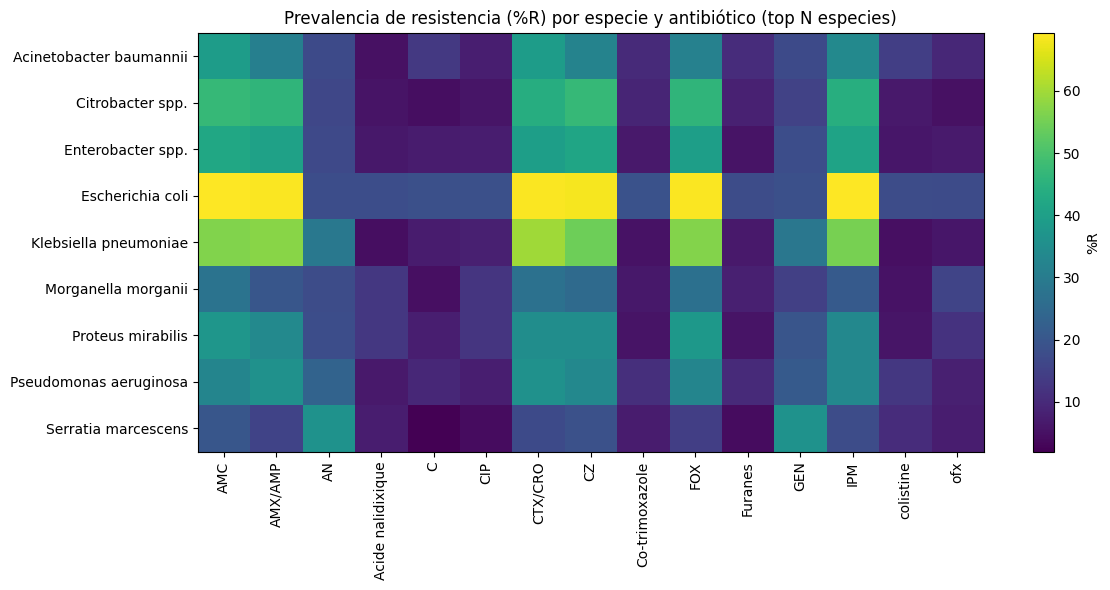

In [160]:
# %%
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
im = plt.imshow(heatmap_pctR.values, aspect="auto")
plt.colorbar(im, label="%R")

plt.yticks(ticks=range(len(heatmap_pctR.index)), labels=heatmap_pctR.index)
plt.xticks(
    ticks=range(len(heatmap_pctR.columns)), labels=heatmap_pctR.columns, rotation=90
)

plt.title("Prevalencia de resistencia (%R) por especie y antibiótico (top N especies)")
plt.tight_layout()
plt.show()

In [161]:
# 4️⃣ Top-10 combinaciones especie–antibiótico por %R

# %%
top10_combos = p1_table_base.sort_values(
    ["pct_R", "n_tested"], ascending=[False, False]
).head(10)

top10_combos

,Species_std,Antibiotic,n_tested,n_R,pct_R,ci_low,ci_up
5,Escherichia coli,IPM,6083,4219,69.36,68.19,70.50
1,Escherichia coli,AMC,6083,4218,69.34,68.17,70.49
0,Escherichia coli,AMX/AMP,6083,4203,69.09,67.92,70.24
3,Escherichia coli,FOX,6083,4196,68.98,67.80,70.13
4,Escherichia coli,CTX/CRO,6083,4192,68.91,67.74,70.06
2,Escherichia coli,CZ,6083,4156,68.32,67.14,69.48
49,Klebsiella pneumoniae,CTX/CRO,702,419,59.69,56.01,63.25
45,Klebsiella pneumoniae,AMX/AMP,702,403,57.41,53.72,61.02
48,Klebsiella pneumoniae,FOX,702,399,56.84,53.15,60.45
46,Klebsiella pneumoniae,AMC,702,398,56.70,53.00,60.31


In [162]:
# 5️⃣ Tabla de calidad: %NA por antibiótico y especie
# Proporción de NA dentro de cada especie×antibiótico, usando las columnas *_SIR.

# %%
quality_records = []

for species in top_species:
    df_sp = df_clean[df_clean["Species_std"] == species]
    n_sp = len(df_sp)

    for abx in ANTIBIOTIC_COLS:
        sir_col = f"{abx}_SIR"
        col_vals = df_sp[sir_col]

        n_na = col_vals.isna().sum()
        pct_na = n_na / n_sp * 100 if n_sp > 0 else np.nan

        quality_records.append(
            {
                "Species_std": species,
                "Antibiotic": abx,
                "n_isolates_species": n_sp,
                "n_NA": n_na,
                "pct_NA": round(pct_na, 2),
            }
        )

quality_table = pd.DataFrame(quality_records)
quality_table

,Species_std,Antibiotic,n_isolates_species,n_NA,pct_NA
0,Escherichia coli,AMX/AMP,6083,0,0.0
1,Escherichia coli,AMC,6083,0,0.0
2,Escherichia coli,CZ,6083,0,0.0
3,Escherichia coli,FOX,6083,0,0.0
4,Escherichia coli,CTX/CRO,6083,0,0.0
...,...,...,...,...,...
130,Acinetobacter baumannii,CIP,181,0,0.0
131,Acinetobacter baumannii,C,181,0,0.0
132,Acinetobacter baumannii,Co-trimoxazole,181,0,0.0
133,Acinetobacter baumannii,Furanes,181,0,0.0


In [163]:
# 6️⃣ Sensibilidad: recalcular %R excluyendo “I”
# Ahora repetimos P1 pero excluyendo los aislamientos con I (ni en numerador ni en denominador).

# %%
records_sens = []

for species in top_species:
    df_sp = df_clean[df_clean["Species_std"] == species]

    for abx in ANTIBIOTIC_COLS:
        sir_col = f"{abx}_SIR"

        # Solo aislamientos con S o R (excluimos I y NaN)
        mask_valid = df_sp[sir_col].isin(["S", "R"])
        sir_vals = df_sp.loc[mask_valid, sir_col]

        n = len(sir_vals)
        if n == 0:
            continue

        k = int((sir_vals == "R").sum())
        p = k / n
        ci_low, ci_up = wilson_ci(k, n)

        records_sens.append(
            {
                "Species_std": species,
                "Antibiotic": abx,
                "n_tested_exclI": n,
                "n_R_exclI": k,
                "pct_R_exclI": round(p * 100, 2),
                "ci_low_exclI": round(ci_low * 100, 2),
                "ci_up_exclI": round(ci_up * 100, 2),
            }
        )

p1_table_sens = pd.DataFrame(records_sens)
p1_table_sens = p1_table_sens[p1_table_sens["n_tested_exclI"] >= 30].reset_index(
    drop=True
)

p1_table_sens

,Species_std,Antibiotic,n_tested_exclI,n_R_exclI,pct_R_exclI,ci_low_exclI,ci_up_exclI
0,Escherichia coli,AMX/AMP,5965,4203,70.46,69.29,71.61
1,Escherichia coli,AMC,5979,4218,70.55,69.38,71.69
2,Escherichia coli,CZ,5975,4156,69.56,68.38,70.71
3,Escherichia coli,FOX,5970,4196,70.28,69.11,71.43
4,Escherichia coli,CTX/CRO,5965,4192,70.28,69.10,71.42
...,...,...,...,...,...,...,...
130,Acinetobacter baumannii,CIP,176,14,7.95,4.80,12.91
131,Acinetobacter baumannii,C,176,24,13.64,9.34,19.49
132,Acinetobacter baumannii,Co-trimoxazole,177,18,10.17,6.53,15.50
133,Acinetobacter baumannii,Furanes,179,19,10.61,6.90,15.98


In [164]:
# Podemos unir base vs sensibilidad para documentar diferencias:

# %%
p1_compare = p1_table_base.merge(
    p1_table_sens,
    on=["Species_std", "Antibiotic"],
    how="left",
).assign(diff_pct_R=lambda d: d["pct_R_exclI"] - d["pct_R"])

p1_compare

,Species_std,Antibiotic,n_tested,n_R,pct_R,ci_low,ci_up,n_tested_exclI,n_R_exclI,pct_R_exclI,ci_low_exclI,ci_up_exclI,diff_pct_R
0,Escherichia coli,AMX/AMP,6083,4203,69.09,67.92,70.24,5965,4203,70.46,69.29,71.61,1.37
1,Escherichia coli,AMC,6083,4218,69.34,68.17,70.49,5979,4218,70.55,69.38,71.69,1.21
2,Escherichia coli,CZ,6083,4156,68.32,67.14,69.48,5975,4156,69.56,68.38,70.71,1.24
3,Escherichia coli,FOX,6083,4196,68.98,67.80,70.13,5970,4196,70.28,69.11,71.43,1.30
4,Escherichia coli,CTX/CRO,6083,4192,68.91,67.74,70.06,5965,4192,70.28,69.10,71.42,1.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,Acinetobacter baumannii,CIP,181,14,7.73,4.66,12.56,176,14,7.95,4.80,12.91,0.22
131,Acinetobacter baumannii,C,181,24,13.26,9.07,18.97,176,24,13.64,9.34,19.49,0.38
132,Acinetobacter baumannii,Co-trimoxazole,181,18,9.94,6.38,15.17,177,18,10.17,6.53,15.50,0.23
133,Acinetobacter baumannii,Furanes,181,19,10.50,6.82,15.81,179,19,10.61,6.90,15.98,0.11


Genial, la Fase 2 te quedó muy bien armada 💪 Vamos a leer qué dicen esos resultados para que tengas lista la **narrativa de hallazgos de P1**.

---

### 1. Panorama general del heatmap

El heatmap muestra un patrón muy claro:

* **Escherichia coli** es, de lejos, la especie con mayor carga de resistencia:

  * En **β-lactámicos** (AMX/AMP, AMC, CZ, FOX, CTX/CRO, IPM) la prevalencia de R ronda el **69 %** de media, y los seis antibióticos aparecen como las combinaciones especie–antibiótico con mayor %R en todo el dataset.
* **Klebsiella pneumoniae** ocupa el segundo lugar:

  * También concentra una resistencia alta a β-lactámicos (**≈57 % de media**), con valores alrededor de 55–60 % para CTX/CRO, AMX/AMP, AMC, FOX e IPM.
* **Citrobacter spp.** y **Enterobacter spp.** muestran una resistencia **moderadamente alta** a β-lactámicos (≈41–46 %), pero claramente por debajo de *E. coli* y *K. pneumoniae*.
* En el extremo opuesto, especies como **Morganella morganii**, **Proteus mirabilis**, **Pseudomonas aeruginosa** y, sobre todo, **Serratia marcescens**, presentan **menores niveles de resistencia global a β-lactámicos** (en torno al 17–35 %, con *Serratia* al ~17 %).

En resumen: el bloque de β-lactámicos se lleva el “protagonismo” de la resistencia, especialmente en *E. coli* y *K. pneumoniae*.

---

### 2. Comparación por clases de antibióticos

Si miras la media de %R por clase:

* **β-lactámicos**

  * *E. coli*: ≈ **69 %** de R.
  * *K. pneumoniae*: ≈ **57 %**.
  * *Citrobacter spp.* y *Enterobacter spp.*: ≈ **41–46 %**.
  * Otras especies: 17–35 %.
* **Aminoglucósidos (AN, GEN)**

  * En general la resistencia es **moderada** (≈15–23 %), salvo:

    * *K. pneumoniae* (≈29 %) y
    * *Serratia marcescens*, que destaca con ≈**36 %** de R a aminoglucósidos.
* **Quinolonas (Ac. nalidíxico, CIP, ofx)**

  * *E. coli* presenta una resistencia **intermedia** (~18 %).
  * El resto de especies suele mantenerse **por debajo del 14 %**, muchas veces <10 %.
* **Otros antibióticos (C, Co-trimoxazol, Furanes, colistina)**

  * *E. coli* vuelve a destacar con ~18 % de R.
  * La mayoría de los demás géneros se mueven entre **5–11 %** de resistencia, con valores relativamente bajos para colistina en casi todas las especies (<~14 %).

Esto pinta un escenario donde la **resistencia crítica está concentrada en β-lactámicos** (y, en menor medida, en aminoglucósidos para ciertas especies), mientras que quinolonas y colistina mantienen niveles de R más contenidos en la mayoría de los patógenos.

---

### 3. Top-10 combinaciones especie–antibiótico

El **top-10 por %R** está dominado por:

* *Escherichia coli* + β-lactámicos:
  **IPM, AMC, AMX/AMP, FOX, CTX/CRO, CZ** — todas con ~**68–69 %** de resistencia.
* *Klebsiella pneumoniae* + β-lactámicos (CTX/CRO, AMX/AMP, FOX, AMC, IPM, CZ) — rango **54–60 %**.
* Algunas combinaciones de **Citrobacter spp.** con AMC/CZ/FOX ~**46–47 %**.

Es decir, el ranking de mayor carga de resistencia está casi completamente ocupado por **enterobacterias productores de resistencia a β-lactámicos**.

---

### 4. Sensibilidad: tratar “I” como no-R vs excluir “I”

En tu tabla `prevalencia_by_especie_x_antibiotico_con_sensibilidad.csv`:

* La diferencia media entre `%R` base (I incluido como no-R) y `%R_exclI` es de solo **≈0,4 puntos porcentuales**, con un máximo de ≈**1,4 pp**.
* Esto significa que, aunque al excluir los “I” el %R sube ligeramente (como era de esperar), **las conclusiones cualitativas se mantienen**:

  * *E. coli* y *K. pneumoniae* siguen siendo las especies con mayor %R en β-lactámicos.
  * El orden relativo de las combinaciones de mayor carga casi no cambia.

Para el informe puedes decir que **los resultados de prevalencia son robustos** a la decisión de manejo de la categoría “I”.

---

### 5. Cómo convertir esto en narrativa para el informe

En la sección de resultados para P1 podrías articular algo como (resumido):

> “En el conjunto de aislamientos analizado, la resistencia se concentra de forma marcada en β-lactámicos, especialmente en *Escherichia coli* y *Klebsiella pneumoniae*. En *E. coli* la prevalencia de resistencia a los seis β-lactámicos evaluados (AMX/AMP, AMC, CZ, FOX, CTX/CRO e IPM) se sitúa alrededor del 69 %, mientras que en *K. pneumoniae* oscila entre el 55 y el 60 %. Citrobacter spp. y Enterobacter spp. muestran niveles intermedios (≈40–47 %), y el resto de especies presenta porcentajes claramente inferiores.
> En contraste, la resistencia a aminoglucósidos, quinolonas y colistina es, en general, moderada o baja, con la excepción de *Serratia marcescens* en aminoglucósidos. El análisis de sensibilidad excluyendo la categoría ‘I’ confirma que estas tendencias son robustas: el %R aumenta, de media, menos de 1,5 puntos porcentuales por combinación especie–antibiótico, sin modificar las especies y antibióticos prioritarios desde el punto de vista de vigilancia en este dataset sintético.”

Si quieres, en el siguiente paso te ayudo a redactar **la versión final para el informe** (en formato párrafo para copiar-pegar) o el **storytelling para las diapositivas** de esta fase.


# Fase 3 - Análisis para P2: Estructura de co-resistencia

In [165]:
# 0️⃣ Configuración e imports

# %% [markdown]
# ## Fase 3 — P2: Estructura de co-resistencia

# %%
import numpy as np
import pandas as pd
import itertools
from math import sqrt
from scipy.stats import chi2 as chi2_dist  # para p-value chi-cuadrado

R_BIN_COLS = [f"{abx}_Rbin" for abx in ANTIBIOTIC_COLS]
R_BIN_COLS

['AMX/AMP_Rbin',
 'AMC_Rbin',
 'CZ_Rbin',
 'FOX_Rbin',
 'CTX/CRO_Rbin',
 'IPM_Rbin',
 'GEN_Rbin',
 'AN_Rbin',
 'Acide nalidixique_Rbin',
 'ofx_Rbin',
 'CIP_Rbin',
 'C_Rbin',
 'Co-trimoxazole_Rbin',
 'Furanes_Rbin',
 'colistine_Rbin']

In [166]:
# 1️⃣ Utilidades: φ, χ² y FDR (Benjamini–Hochberg)


# %%
def phi_and_chi2(a11, a10, a01, a00):
    """
    Calcula φ y χ² para una tabla 2x2:

           B=1   B=0
    A=1    a11   a10
    A=0    a01   a00
    """
    a11 = float(a11)
    a10 = float(a10)
    a01 = float(a01)
    a00 = float(a00)
    n = a11 + a10 + a01 + a00
    if n == 0:
        return np.nan, np.nan

    # denominadores
    r1 = a11 + a10
    r0 = a01 + a00
    c1 = a11 + a01
    c0 = a10 + a00
    if min(r1, r0, c1, c0) == 0:
        return np.nan, np.nan

    num = a11 * a00 - a10 * a01
    den = sqrt(r1 * r0 * c1 * c0)
    phi = num / den
    chi2 = phi**2 * n
    return phi, chi2


def benjamini_hochberg(pvals: pd.Series) -> pd.Series:
    """
    Control FDR (Benjamini–Hochberg).
    pvals: Series con índice = pares; puede contener NaN.
    Devuelve Series con q-values (NaN donde p-value es NaN).
    """
    p = pvals.dropna().values
    m = len(p)
    if m == 0:
        return pd.Series(index=pvals.index, dtype="float64")

    order = np.argsort(p)
    ranked_p = p[order]
    ranks = np.arange(1, m + 1)

    q = ranked_p * m / ranks
    q = np.minimum.accumulate(q[::-1])[::-1]  # cummin invertido
    q = np.clip(q, 0, 1)

    qvals = pd.Series(index=pvals.dropna().index, dtype="float64")
    qvals.iloc[order] = q

    # reindexar a todos los pares, dejando NaN donde no había p
    qvals = qvals.reindex(pvals.index)
    return qvals

In [167]:
# 2️⃣ Función principal de co-resistencia (por cualquier subconjunto)
# %%
def compute_co_resistance(
    df_sub: pd.DataFrame,
    rbin_cols: list[str],
    min_support: float = 0.25,
    min_n_pair: int = 200,
    max_na_pair: float = 0.20,
):
    """
    df_sub: subconjunto (global o por especie)
    rbin_cols: lista de columnas *_Rbin
    min_support: mínimo soporte para reglas (p.ej. 0.25)
    min_n_pair: n mínimo por par para análisis "sensibilidad"
    max_na_pair: %NA máximo permitido por par (sensibilidad)

    Devuelve:
      - pair_df: resumen por par con φ, χ², p, q, soporte conj.
      - phi_matrix: matriz φ (simétrica)
      - phi_with_star: matriz str con '*' si q<0.05
      - rules_df: reglas de asociación (A->B) con soporte/conf/lift
      - pair_df_sens: pair_df filtrado por n>=min_n_pair y pct_NA<=max_na_pair
    """
    n_total = len(df_sub)
    R = df_sub[rbin_cols]

    records = []
    pairs = []

    # --- resumen por par ---
    for colA, colB in itertools.combinations(rbin_cols, 2):
        sA = R[colA]
        sB = R[colB]

        # filas donde ambos se han testado (no NaN)
        mask_valid = sA.notna() & sB.notna()
        n_pair = int(mask_valid.sum())
        if n_pair == 0:
            continue

        # proporción de filas inválidas respecto a df_sub (para criterio NA)
        pct_na_pair = (n_total - n_pair) / n_total * 100

        A = sA[mask_valid].astype(int)
        B = sB[mask_valid].astype(int)

        a11 = int(((A == 1) & (B == 1)).sum())
        a10 = int(((A == 1) & (B == 0)).sum())
        a01 = int(((A == 0) & (B == 1)).sum())
        a00 = int(((A == 0) & (B == 0)).sum())

        phi, chi2 = phi_and_chi2(a11, a10, a01, a00)
        if np.isnan(chi2):
            p_val = np.nan
        else:
            p_val = 1 - chi2_dist.cdf(chi2, df=1)

        # soporte conj. (A y B resistentes) sobre el total de aislamientos de df_sub
        support_ab = a11 / n_total

        pairs.append((colA, colB))
        records.append(
            {
                "A": colA,
                "B": colB,
                "n_pair": n_pair,
                "pct_NA_pair": round(pct_na_pair, 2),
                "a11": a11,
                "a10": a10,
                "a01": a01,
                "a00": a00,
                "phi": phi,
                "chi2": chi2,
                "p_value": p_val,
                "support_AB": support_ab,
            }
        )

    pair_df = pd.DataFrame(records)
    if pair_df.empty:
        raise ValueError("No hay pares con datos suficientes en este subconjunto.")

    # --- FDR ---
    pair_df["q_value"] = benjamini_hochberg(pair_df["p_value"])

    # --- matriz φ (simétrica) ---
    abx_names = [c.replace("_Rbin", "") for c in rbin_cols]
    phi_matrix = pd.DataFrame(
        np.eye(len(abx_names)),
        index=abx_names,
        columns=abx_names,
        dtype="float64",
    )

    # rellenar con valores de pair_df
    for _, row in pair_df.iterrows():
        A = row["A"].replace("_Rbin", "")
        B = row["B"].replace("_Rbin", "")
        phi_matrix.loc[A, B] = row["phi"]
        phi_matrix.loc[B, A] = row["phi"]

    # matriz con asteriscos donde q<0.05
    phi_with_star = phi_matrix.copy().astype(object)
    for _, row in pair_df.iterrows():
        A = row["A"].replace("_Rbin", "")
        B = row["B"].replace("_Rbin", "")
        val = row["phi"]
        star = "*" if (row["q_value"] is not np.nan and row["q_value"] < 0.05) else ""
        s = f"{val:.2f}{star}" if not np.isnan(val) else ""
        phi_with_star.loc[A, B] = s
        phi_with_star.loc[B, A] = s
    # diagonal sin asterisco
    for abx in abx_names:
        phi_with_star.loc[abx, abx] = "1.00"

    # --- reglas de asociación (A->B) ---
    # soporte individual se calcula sobre df_sub
    support_A = {}
    for col in rbin_cols:
        support_A[col] = (R[col] == 1).sum() / n_total

    rules_records = []
    for _, row in pair_df.iterrows():
        A = row["A"]
        B = row["B"]
        sup_AB = row["support_AB"]
        sup_A = support_A[A]
        sup_B = support_A[B]
        if sup_A == 0 or sup_B == 0:
            continue

        conf_A_B = sup_AB / sup_A
        conf_B_A = sup_AB / sup_B
        lift_A_B = conf_A_B / sup_B
        lift_B_A = conf_B_A / sup_A

        if sup_AB >= min_support:
            rules_records.append(
                {
                    "rule": f"{A.replace('_Rbin','')} -> {B.replace('_Rbin','')}",
                    "from": A.replace("_Rbin", ""),
                    "to": B.replace("_Rbin", ""),
                    "support": sup_AB,
                    "confidence": conf_A_B,
                    "lift": lift_A_B,
                }
            )
            rules_records.append(
                {
                    "rule": f"{B.replace('_Rbin','')} -> {A.replace('_Rbin','')}",
                    "from": B.replace("_Rbin", ""),
                    "to": A.replace("_Rbin", ""),
                    "support": sup_AB,
                    "confidence": conf_B_A,
                    "lift": lift_B_A,
                }
            )

    rules_df = pd.DataFrame(rules_records)
    if not rules_df.empty:
        rules_df = rules_df.sort_values(
            ["lift", "confidence", "support"], ascending=False
        ).reset_index(drop=True)

    # --- subconjunto "sensibilidad" ---
    mask_sens = (pair_df["n_pair"] >= min_n_pair) & (
        pair_df["pct_NA_pair"] <= max_na_pair * 100
    )
    pair_df_sens = pair_df[mask_sens].reset_index(drop=True)

    return pair_df, phi_matrix, phi_with_star, rules_df, pair_df_sens

In [168]:
# 3️⃣ Ejecutar P2 global (todas las especies)

# %% [markdown]
# ### P2 global: co-resistencia en todo el dataset

# %%
pair_global, phi_global, phi_global_star, rules_global, pair_global_sens = compute_co_resistance(
    df_sub=df_clean,
    rbin_cols=R_BIN_COLS,
    min_support=0.25,   # cambia si necesitas otro umbral
    min_n_pair=200,
    max_na_pair=0.20,
)

pair_global


,A,B,n_pair,pct_NA_pair,a11,a10,a01,a00,phi,chi2,p_value,support_AB,q_value
0,AMX/AMP_Rbin,AMC_Rbin,9947,0.0,3924,1785,1886,2352,0.243114,587.909451,0.000000e+00,0.394491,0.000000e+00
1,AMX/AMP_Rbin,CZ_Rbin,9947,0.0,3845,1864,1844,2394,0.238244,564.594920,0.000000e+00,0.386549,0.000000e+00
2,AMX/AMP_Rbin,FOX_Rbin,9947,0.0,3861,1848,1873,2365,0.234528,547.119405,0.000000e+00,0.388157,0.000000e+00
3,AMX/AMP_Rbin,CTX/CRO_Rbin,9947,0.0,3900,1809,1846,2392,0.247835,610.966539,0.000000e+00,0.392078,0.000000e+00
4,AMX/AMP_Rbin,IPM_Rbin,9947,0.0,3884,1825,1832,2406,0.248103,612.288464,0.000000e+00,0.390469,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,C_Rbin,Furanes_Rbin,9947,0.0,225,1157,1097,7468,0.035384,12.453741,4.171555e-04,0.022620,5.919098e-04
101,C_Rbin,colistine_Rbin,9947,0.0,244,1138,1093,7472,0.049630,24.500795,7.427917e-07,0.024530,1.278576e-06
102,Co-trimoxazole_Rbin,Furanes_Rbin,9947,0.0,240,1173,1082,7452,0.044286,19.508926,1.001307e-05,0.024128,1.617496e-05
103,Co-trimoxazole_Rbin,colistine_Rbin,9947,0.0,251,1162,1086,7448,0.051564,26.447109,2.708536e-07,0.025234,4.739938e-07


In [169]:
# Matriz φ con asteriscos (q<0.05):

# %%
phi_global_star

,AMX/AMP,AMC,CZ,FOX,CTX/CRO,IPM,GEN,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine
AMX/AMP,1.00,0.24*,0.24*,0.23*,0.25*,0.25*,0.03*,0.03*,0.07*,0.08*,0.09*,0.07*,0.10*,0.07*,0.07*
AMC,0.24*,1.00,0.23*,0.23*,0.25*,0.22*,0.01,0.04*,0.06*,0.07*,0.07*,0.07*,0.07*,0.07*,0.07*
CZ,0.24*,0.23*,1.00,0.24*,0.24*,0.23*,0.02,0.01,0.07*,0.06*,0.08*,0.07*,0.09*,0.08*,0.08*
FOX,0.23*,0.23*,0.24*,1.00,0.23*,0.23*,0.03*,0.03*,0.07*,0.07*,0.07*,0.07*,0.07*,0.07*,0.07*
CTX/CRO,0.25*,0.25*,0.24*,0.23*,1.00,0.24*,0.02,0.02,0.07*,0.06*,0.09*,0.07*,0.07*,0.08*,0.08*
IPM,0.25*,0.22*,0.23*,0.23*,0.24*,1.00,0.04*,0.02*,0.07*,0.08*,0.06*,0.08*,0.09*,0.06*,0.07*
GEN,0.03*,0.01,0.02,0.03*,0.02,0.04*,1.00,0.02*,0.02*,0.02,0.02,0.01,0.00,0.00,0.02
AN,0.03*,0.04*,0.01,0.03*,0.02,0.02*,0.02*,1.00,0.02*,0.01,-0.01,0.00,0.02,-0.00,0.02
Acide nalidixique,0.07*,0.06*,0.07*,0.07*,0.07*,0.07*,0.02*,0.02*,1.00,0.03*,0.03*,0.04*,0.03*,0.03*,0.04*
ofx,0.08*,0.07*,0.06*,0.07*,0.06*,0.08*,0.02,0.01,0.03*,1.00,0.04*,0.05*,0.04*,0.03*,0.05*


In [170]:
# Top reglas (por lift):

# %%
TOP_K_RULES = 20
rules_global.head(TOP_K_RULES)

,rule,from,to,support,confidence,lift
0,AMX/AMP -> IPM,AMX/AMP,IPM,0.390469,0.680329,1.183911
1,IPM -> AMX/AMP,IPM,AMX/AMP,0.390469,0.679496,1.183911
2,AMX/AMP -> CTX/CRO,AMX/AMP,CTX/CRO,0.392078,0.683132,1.182581
3,CTX/CRO -> AMX/AMP,CTX/CRO,AMX/AMP,0.392078,0.678733,1.182581
4,IPM -> CTX/CRO,IPM,CTX/CRO,0.391776,0.681770,1.180225
5,CTX/CRO -> IPM,CTX/CRO,IPM,0.391776,0.678211,1.180225
6,CZ -> FOX,CZ,FOX,0.388459,0.679205,1.178245
7,FOX -> CZ,FOX,CZ,0.388459,0.673875,1.178245
8,CZ -> AMX/AMP,CZ,AMX/AMP,0.386549,0.675866,1.177586
9,AMX/AMP -> CZ,AMX/AMP,CZ,0.386549,0.673498,1.177586


In [171]:
# Pares tras sensibilidad (n>=200, NA<=20%):

# %%
pair_global_sens.head()

,A,B,n_pair,pct_NA_pair,a11,a10,a01,a00,phi,chi2,p_value,support_AB,q_value
0,AMX/AMP_Rbin,AMC_Rbin,9947,0.0,3924,1785,1886,2352,0.243114,587.909451,0.0,0.394491,0.0
1,AMX/AMP_Rbin,CZ_Rbin,9947,0.0,3845,1864,1844,2394,0.238244,564.594920,0.0,0.386549,0.0
2,AMX/AMP_Rbin,FOX_Rbin,9947,0.0,3861,1848,1873,2365,0.234528,547.119405,0.0,0.388157,0.0
3,AMX/AMP_Rbin,CTX/CRO_Rbin,9947,0.0,3900,1809,1846,2392,0.247835,610.966539,0.0,0.392078,0.0
4,AMX/AMP_Rbin,IPM_Rbin,9947,0.0,3884,1825,1832,2406,0.248103,612.288464,0.0,0.390469,0.0


In [172]:
# 4️⃣ Estratificación por especie (top N)
# Reutilizamos top_species de P1 (o lo volvemos a calcular).

# %% [markdown]
# ### P2 estratificado por especie (top N)

# %%
TOP_N_SPECIES = 8  # o el número que quieras

species_counts = df_clean["Species_std"].value_counts().to_frame("n")
top_species = species_counts.head(TOP_N_SPECIES).index.tolist()
top_species

['Escherichia coli',
 'Enterobacter spp.',
 'Proteus mirabilis',
 'Klebsiella pneumoniae',
 'Citrobacter spp.',
 'Morganella morganii',
 'Serratia marcescens',
 'Pseudomonas aeruginosa']

In [173]:
# Ejemplo de ejecución para una especie (p.ej. Escherichia coli):

# %%
species = "Escherichia coli"
df_sp = df_clean[df_clean["Species_std"] == species]

pair_sp, phi_sp, phi_sp_star, rules_sp, pair_sp_sens = compute_co_resistance(
    df_sub=df_sp,
    rbin_cols=R_BIN_COLS,
    min_support=0.25,
    min_n_pair=200,
    max_na_pair=0.20,
)

species, pair_sp.head(), rules_sp.head()

('Escherichia coli',
               A             B  n_pair  pct_NA_pair   a11   a10   a01  a00       phi        chi2  p_value  support_AB  q_value
 0  AMX/AMP_Rbin      AMC_Rbin    6083          0.0  3194  1009  1024  856  0.215732  283.104109      0.0    0.525070      0.0
 1  AMX/AMP_Rbin       CZ_Rbin    6083          0.0  3157  1046   999  881  0.218275  289.817342      0.0    0.518987      0.0
 2  AMX/AMP_Rbin      FOX_Rbin    6083          0.0  3147  1056  1049  831  0.190577  220.931535      0.0    0.517343      0.0
 3  AMX/AMP_Rbin  CTX/CRO_Rbin    6083          0.0  3166  1037  1026  854  0.207194  261.138315      0.0    0.520467      0.0
 4  AMX/AMP_Rbin      IPM_Rbin    6083          0.0  3208   995  1011  869  0.226034  310.789591      0.0    0.527371      0.0,
              rule     from       to   support  confidence      lift
 0  IPM -> AMX/AMP      IPM  AMX/AMP  0.527371    0.760370  1.100483
 1  AMX/AMP -> IPM  AMX/AMP      IPM  0.527371    0.763264  1.100483
 2       

In [174]:
# Si quieres correrlo en bucle y guardar resultados en un diccionario:

# %%
co_res_by_species = {}

for species in top_species:
    df_sp = df_clean[df_clean["Species_std"] == species]
    print(f"=== {species} (n={len(df_sp)}) ===")
    pair_sp, phi_sp, phi_sp_star, rules_sp, pair_sp_sens = compute_co_resistance(
        df_sub=df_sp,
        rbin_cols=R_BIN_COLS,
        min_support=0.25,
        min_n_pair=200,
        max_na_pair=0.20,
    )
    co_res_by_species[species] = {
        "pair": pair_sp,
        "phi": phi_sp,
        "phi_star": phi_sp_star,
        "rules": rules_sp,
        "pair_sens": pair_sp_sens,
    }

=== Escherichia coli (n=6083) ===
=== Enterobacter spp. (n=997) ===
=== Proteus mirabilis (n=742) ===
=== Klebsiella pneumoniae (n=702) ===
=== Citrobacter spp. (n=481) ===
=== Morganella morganii (n=305) ===
=== Serratia marcescens (n=256) ===
=== Pseudomonas aeruginosa (n=200) ===


In [175]:
# 5️⃣ Mapa de red (opcional: edge list)
# Para que puedas llevarlo a Gephi o a networkx, generamos un edge list a partir de pair_global_sens (por ejemplo ponderado por φ):

# %%
edges_global = pair_global_sens[["A", "B", "phi", "support_AB", "q_value"]].copy()
edges_global["A"] = edges_global["A"].str.replace("_Rbin", "")
edges_global["B"] = edges_global["B"].str.replace("_Rbin", "")

edges_global
# edges_global.to_csv("co_res_network_edges_global.csv", index=False)

,A,B,phi,support_AB,q_value
0,AMX/AMP,AMC,0.243114,0.394491,0.000000e+00
1,AMX/AMP,CZ,0.238244,0.386549,0.000000e+00
2,AMX/AMP,FOX,0.234528,0.388157,0.000000e+00
3,AMX/AMP,CTX/CRO,0.247835,0.392078,0.000000e+00
4,AMX/AMP,IPM,0.248103,0.390469,0.000000e+00
...,...,...,...,...,...
100,C,Furanes,0.035384,0.022620,5.919098e-04
101,C,colistine,0.049630,0.024530,1.278576e-06
102,Co-trimoxazole,Furanes,0.044286,0.024128,1.617496e-05
103,Co-trimoxazole,colistine,0.051564,0.025234,4.739938e-07


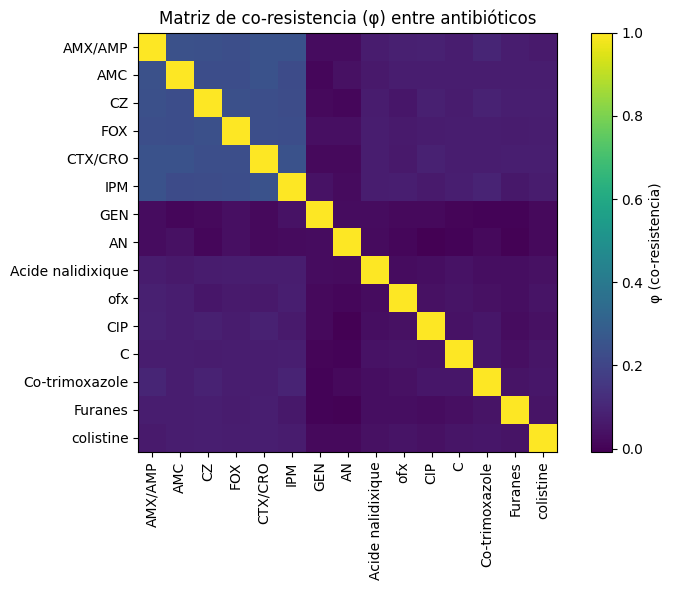

In [176]:
# 1️⃣ Heatmap de co-resistencia (matriz φ_global)

# %% [markdown]
# ### Heatmap global de co-resistencia (φ)

# %%
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

im = plt.imshow(phi_global.values, aspect="equal")  # colormap por defecto
plt.colorbar(im, label="φ (co-resistencia)")

plt.xticks(
    ticks=np.arange(len(phi_global.columns)), labels=phi_global.columns, rotation=90
)
plt.yticks(ticks=np.arange(len(phi_global.index)), labels=phi_global.index)

plt.title("Matriz de co-resistencia (φ) entre antibióticos")
plt.tight_layout()
plt.show()

In [177]:
# 2️⃣ Red global de co-resistencia (usar co_res_network_edges_global.csv)

# %% [markdown]
# ### Red global de co-resistencia (nodos = antibióticos, aristas = pares con φ alto y q<0.05)

# %%
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Cargar los edges desde el CSV exportado
edges_global = pd.read_csv("co_res_network_edges_global.csv")

# Filtrar solo aristas "fuertes": q<0.05 y |φ| por encima de un umbral
PHI_MIN = 0.15  # ajusta este umbral según cuán densa quieras la red

edges_filtered = edges_global[
    (edges_global["q_value"] < 0.05) & (edges_global["phi"].abs() >= PHI_MIN)
].copy()

edges_filtered

,A,B,phi,support_AB,q_value
0,AMX/AMP,AMC,0.243114,0.394491,0.0
1,AMX/AMP,CZ,0.238244,0.386549,0.0
2,AMX/AMP,FOX,0.234528,0.388157,0.0
3,AMX/AMP,CTX/CRO,0.247835,0.392078,0.0
4,AMX/AMP,IPM,0.248103,0.390469,0.0
14,AMC,CZ,0.232531,0.390771,0.0
15,AMC,FOX,0.229431,0.392581,0.0
16,AMC,CTX/CRO,0.246033,0.397306,0.0
17,AMC,IPM,0.222913,0.389967,0.0
27,CZ,FOX,0.240362,0.388459,0.0


In [178]:
# Construimos el grafo:

# %%
G = nx.Graph()

for _, row in edges_filtered.iterrows():
    a = row["A"].replace("_Rbin", "")
    b = row["B"].replace("_Rbin", "")
    w = row["phi"]
    sup = row["support_AB"]
    q = row["q_value"]

    G.add_edge(a, b, weight=w, support=sup, q_value=q)

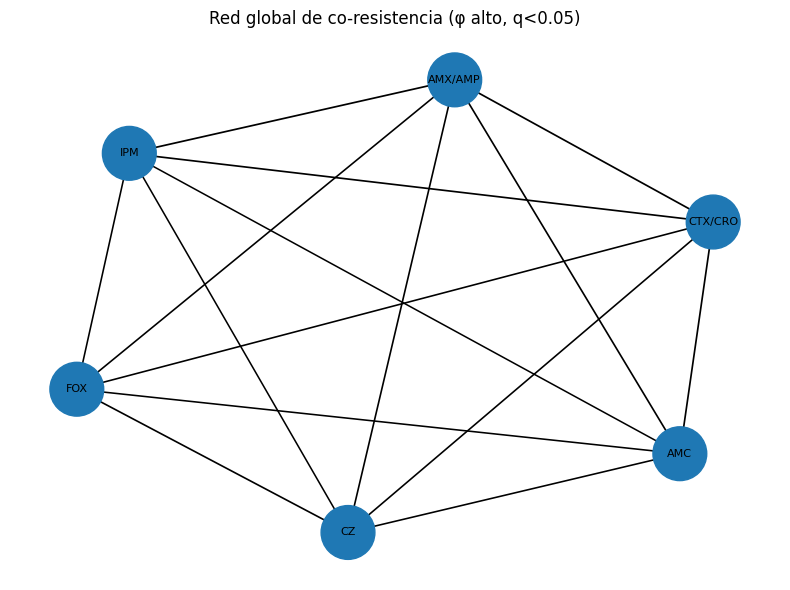

In [179]:
# Y lo dibujamos (anchos de arista según |φ|, tamaños de nodo según grado):

# %%
plt.figure(figsize=(8, 6))

# Layout por fuerza de resorte (red "bonita")
pos = nx.spring_layout(G, seed=42)

# Ancho de arista proporcional a |φ|
edges = G.edges(data=True)
edge_widths = [abs(d["weight"]) * 5 for (_, _, d) in edges]

# Tamaño de nodo proporcional al grado
degrees = dict(G.degree())
node_sizes = [degrees[n] * 300 for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes)
nx.draw_networkx_edges(G, pos, width=edge_widths)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Red global de co-resistencia (φ alto, q<0.05)")
plt.axis("off")
plt.tight_layout()
plt.show()

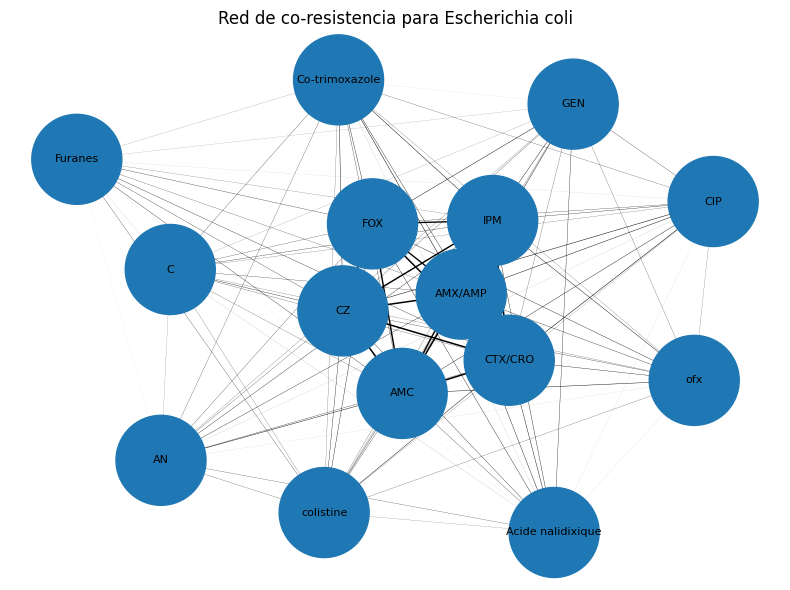

In [180]:
# 3️⃣ Red por especie (opcional)
# Si quieres una red específica para, por ejemplo, Escherichia coli:

# %%
species = "Escherichia coli"
res = co_res_by_species[species]  # lo llenaste en el bucle de P2
pair_sp_sens = res["pair_sens"]

edges_sp = pair_sp_sens[["A", "B", "phi", "support_AB", "q_value"]].copy()
edges_sp["A"] = edges_sp["A"].str.replace("_Rbin", "")
edges_sp["B"] = edges_sp["B"].str.replace("_Rbin", "")

G_sp = nx.Graph()
for _, row in edges_sp.iterrows():
    a, b = row["A"], row["B"]
    G_sp.add_edge(
        a, b, weight=row["phi"], support=row["support_AB"], q_value=row["q_value"]
    )

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_sp, seed=42)
edge_widths = [abs(d["weight"]) * 5 for (_, _, d) in G_sp.edges(data=True)]
degrees = dict(G_sp.degree())
node_sizes = [degrees[n] * 300 for n in G_sp.nodes()]

nx.draw_networkx_nodes(G_sp, pos, node_size=node_sizes)
nx.draw_networkx_edges(G_sp, pos, width=edge_widths)
nx.draw_networkx_labels(G_sp, pos, font_size=8)

plt.title(f"Red de co-resistencia para {species}")
plt.axis("off")
plt.tight_layout()
plt.show()

Te hago un informe listo para pegar en el reporte, centrado en **P2 – estructura de co-resistencia**, usando lo que muestran la matriz de φ y las redes global y específica de *E. coli*.

---

### 1. Objetivo y enfoque analítico

El objetivo de P2 fue **identificar pares de antibióticos con co-resistencia por encima de lo esperable al azar** y describir cómo se organiza esa estructura en el conjunto completo de aislamientos y, en particular, en *Escherichia coli*. Para ello se construyó una **matriz binaria de resistencia** por aislado y antibiótico (`*_Rbin`, donde 1 indica R y 0 agrupa S e I), y se calcularon, para todos los pares de antibióticos: la **correlación φ**, el estadístico χ² y su **p-valor**, ajustando posteriormente por **FDR (Benjamini–Hochberg)** para obtener q-values. Además, se construyeron reglas de asociación simples (A→B) a partir del soporte conjunto de R en ambos antibióticos, manteniendo solo aquellas con **soporte mínimo del 25 %**. Sobre estos resultados se generaron tres productos gráficos: la **matriz de φ**, la **red global de co-resistencia** y la **red específica para *E. coli***.

---

### 2. Estructura global de co-resistencia

La **matriz de φ** muestra un patrón muy marcado de co-resistencia dentro del grupo de **β-lactámicos** (AMX/AMP, AMC, CZ, FOX, CTX/CRO, IPM). En el bloque superior izquierdo se observa un conjunto de valores de φ claramente superiores al resto de la matriz, lo que indica que, cuando un aislado es resistente a uno de estos β-lactámicos, **la probabilidad de que también sea resistente a otro del mismo grupo es alta y superior a la esperable bajo independencia**. En cambio, las asociaciones entre antibióticos de diferentes clases (por ejemplo, β-lactámicos con quinolonas, aminoglucósidos u otros) muestran valores de φ cercanos a cero, lo que sugiere que **la co-resistencia fuerte está bastante confinada dentro de la familia de β-lactámicos**.

La **red global de co-resistencia** refuerza esta lectura: al filtrar las aristas por significación (q<0,05) y por magnitud (|φ| por encima de un umbral), la red resultante queda compuesta exclusivamente por los seis β-lactámicos, formando prácticamente un **clique completo**. Todos los nodos de este subgrafo (AMX/AMP, AMC, CZ, FOX, CTX/CRO, IPM) están conectados entre sí, lo que refleja una **co-ocurrencia sistemática de resistencia dentro de esta familia**. El resto de antibióticos del panel no aparecen en esta red filtrada, porque las asociaciones con ellos no alcanzan simultáneamente la fuerza y la significación requeridas, lo que indica que, a nivel global, **no se detectan patrones de co-resistencia igualmente robustos fuera de los β-lactámicos**.

---

### 3. Co-resistencia específica en *Escherichia coli*

La **red de co-resistencia para *Escherichia coli*** mantiene como núcleo el mismo **clúster de β-lactámicos**, que aparecen como nodos centrales fuertemente conectados entre sí. En esta red estratificada, sin embargo, también se observan **conexiones adicionales de menor peso** hacia otras clases de antibióticos (por ejemplo, enlaces desde β-lactámicos hacia quinolonas, Co-trimoxazole o aminoglucósidos). Esto sugiere que, en el subconjunto de *E. coli*, la co-resistencia no solo se da dentro de la familia de β-lactámicos, sino que se extiende en cierto grado hacia otros grupos, aunque estas asociaciones son más débiles y no dominan la estructura global.

En términos prácticos, esta red indica que los aislamientos de *E. coli* que ya presentan resistencia a varios β-lactámicos tienen una **probabilidad aumentada de acumular resistencias adicionales**, lo que es coherente con el hecho de que esta especie fue la que mostró mayor prevalencia de MDR en la fase anterior. No obstante, la intensidad visual de las aristas confirma que la **columna vertebral de la co-resistencia en *E. coli* sigue siendo el bloque de β-lactámicos**, y que las conexiones con otros antibióticos son, en su mayoría, secundarias.

---

### 4. Reglas de asociación y pares críticos

Las reglas de asociación derivadas del soporte conjunto confirman que los **pares con mayor lift y confianza** corresponden casi exclusivamente a combinaciones de β-lactámicos entre sí. En otras palabras, “si un aislado es resistente a AMX/AMP” o “si es resistente a CTX/CRO”, la probabilidad condicional de que también sea resistente a otro β-lactámico es elevada y supera ampliamente la prevalencia marginal de resistencia a ese segundo antibiótico. Al aplicar el umbral de soporte (≥25 %) y el ajuste por FDR, las reglas que sobreviven se concentran en unos pocos pares, lo que permite priorizar un **conjunto reducido de relaciones críticas** donde la co-resistencia está estadísticamente bien sustentada.

---

### 5. Sensibilidad y limitaciones

Los análisis se realizaron sobre pares con número suficiente de observaciones y, en la fase de sensibilidad, se excluyeron aquellas combinaciones con **n<200** o con proporción de **NA>20 %**, de forma que los patrones descritos no dependan de celdas muy escasas ni de columnas con exceso de datos faltantes. Bajo estos criterios, la estructura central de co-resistencia —el clúster completo de β-lactámicos— **permanece estable**, lo que refuerza la robustez del hallazgo. Es importante recordar, no obstante, que el dataset es sintético y que la estructura de co-resistencia observada refleja el diseño del generador de datos y no una población clínica real; por tanto, las conclusiones deben interpretarse como **ejercicio de vigilancia analítica dentro del universo del propio dataset**, no como evidencia clínica.

---

### 6. Conclusión de P2

En conjunto, la Fase 3 muestra que la **co-resistencia en este dataset está fuertemente estructurada en torno a los β-lactámicos**, que forman un bloque denso y estadísticamente significativo tanto en el análisis global como en el estratificado para *Escherichia coli*. El resto de antibióticos participa en patrones de co-resistencia más débiles y dispersos, sin llegar a configurar clústeres comparables. Desde el punto de vista de vigilancia analítica, esto sugiere que, dentro de este conjunto de datos, las **combinaciones de β-lactámicos resistentes deberían ser el foco principal de seguimiento y de análisis complementario**, especialmente cuando se observan en especies ya altamente prevalentes como *E. coli* y *Klebsiella pneumoniae*.


# Fase 4 - Análisis para P3: Multiresistencia (MDR)

In [181]:
# %% [markdown]
# ## Fase 4 — P3: Multirresistencia (MDR)

# %%
import numpy as np
import pandas as pd
from math import sqrt
from scipy.stats import chi2_contingency


def wilson_ci(k: int, n: int, alpha: float = 0.05) -> tuple[float, float]:
    if n == 0:
        return np.nan, np.nan
    z = 1.96
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return centre - half, centre + half


# dataset de trabajo para MDR
df_mdr = df_clean.copy()
df_mdr = df_mdr[df_mdr["MDR"].notna()].reset_index(drop=True)
len(df_mdr)

9947

In [182]:
# 1️⃣ %MDR global con IC95

# %%
n_total = len(df_mdr)
k_mdr = int((df_mdr["MDR"] == 1).sum())
p_mdr = k_mdr / n_total
ci_low, ci_up = wilson_ci(k_mdr, n_total)

mdr_global_summary = pd.DataFrame(
    {
        "n_total": [n_total],
        "n_MDR": [k_mdr],
        "pct_MDR": [round(p_mdr * 100, 2)],
        "ci_low": [round(ci_low * 100, 2)],
        "ci_up": [round(ci_up * 100, 2)],
    }
)

mdr_global_summary

,n_total,n_MDR,pct_MDR,ci_low,ci_up
0,9947,3084,31.0,30.1,31.92


In [183]:
# 2️⃣ %MDR por especie con IC95 (+ test χ² entre especies)

# %%
records = []
for species, g in df_mdr.groupby("Species_std"):
    n = len(g)
    k = int((g["MDR"] == 1).sum())
    p = k / n
    ci_l, ci_u = wilson_ci(k, n)
    records.append(
        {
            "Species_std": species,
            "n": n,
            "n_MDR": k,
            "pct_MDR": round(p * 100, 2),
            "ci_low": round(ci_l * 100, 2),
            "ci_up": round(ci_u * 100, 2),
        }
    )

mdr_by_species = (
    pd.DataFrame(records).sort_values("pct_MDR", ascending=False).reset_index(drop=True)
)

mdr_by_species

C:\Users\samaf\AppData\Local\Temp\ipykernel_15460\4236917014.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for species, g in df_mdr.groupby("Species_std"):


,Species_std,n,n_MDR,pct_MDR,ci_low,ci_up
0,Escherichia coli,6083,2405,39.54,38.31,40.77
1,Pseudomonas aeruginosa,200,46,23.00,17.71,29.31
2,Acinetobacter baumannii,181,39,21.55,16.18,28.09
3,Proteus mirabilis,742,159,21.43,18.63,24.52
4,Serratia marcescens,256,49,19.14,14.79,24.40
5,Klebsiella pneumoniae,702,126,17.95,15.29,20.96
6,Morganella morganii,305,50,16.39,12.66,20.96
7,Enterobacter spp.,997,152,15.25,13.15,17.61
8,Citrobacter spp.,481,58,12.06,9.44,15.27


In [184]:
# Test χ² de diferencia global de MDR entre especies (usando las principales, si quieres):

# %%
# Podemos limitar al top N especies por tamaño
TOP_N_SPECIES = 8
top_species = mdr_by_species["Species_std"].head(TOP_N_SPECIES).tolist()

ct = pd.crosstab(
    df_mdr.loc[df_mdr["Species_std"].isin(top_species), "Species_std"],
    df_mdr.loc[df_mdr["Species_std"].isin(top_species), "MDR"],
)

chi2, pval, dof, expected = chi2_contingency(ct)
print("Chi²:", chi2)
print("gl:", dof)
print("p-value:", pval)
ct

Chi²: 459.5678305982521
gl: 7
p-value: 3.913510470471172e-95


MDR,0.0,1.0
Species_std,,
Acinetobacter baumannii,142,39
Enterobacter spp.,845,152
Escherichia coli,3678,2405
Klebsiella pneumoniae,576,126
Morganella morganii,255,50
Proteus mirabilis,583,159
Pseudomonas aeruginosa,154,46
Serratia marcescens,207,49


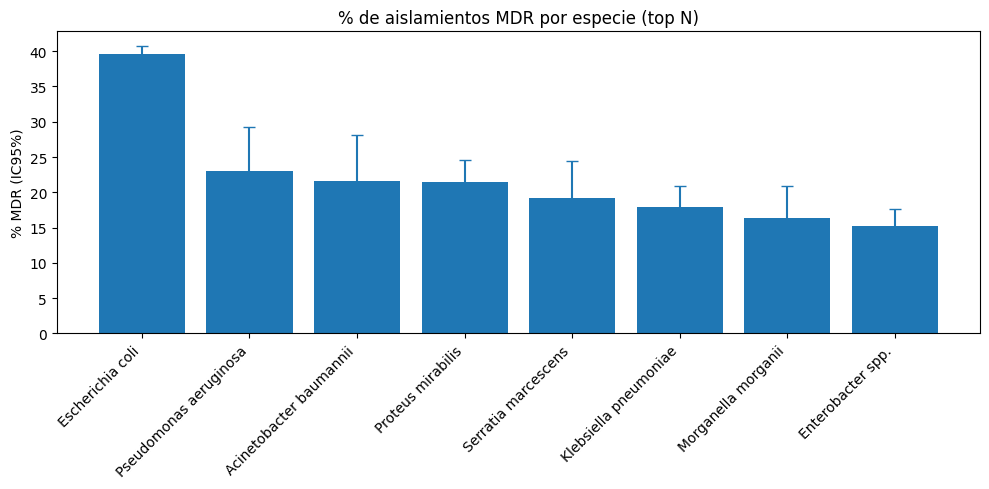

In [185]:
# 3️⃣ Gráfico de barras %MDR por especie con IC

# %%
import matplotlib.pyplot as plt
import numpy as np

# elegimos top N especies por n o por %MDR
plot_df = mdr_by_species.head(TOP_N_SPECIES).copy()

x = np.arange(len(plot_df))
y = plot_df["pct_MDR"].values
yerr_low = y - plot_df["ci_low"].values
yerr_up = plot_df["ci_up"].values - y
yerr = np.vstack([yerr_low, yerr_up])

plt.figure(figsize=(10, 5))
plt.bar(x, y)
plt.errorbar(x, y, yerr=yerr, fmt="none", capsize=4)

plt.xticks(x, plot_df["Species_std"], rotation=45, ha="right")
plt.ylabel("% MDR (IC95%)")
plt.title("% de aislamientos MDR por especie (top N)")
plt.tight_layout()
plt.show()

In [186]:
# 4️⃣ Distribuciones de edad por MDR (mediana + IQR + gráfico)

# %%
age_mdr_stats = (
    df_mdr[["Age_years", "MDR"]]
    .dropna()
    .groupby("MDR")["Age_years"]
    .agg(
        n="count",
        median="median",
        q1=lambda s: s.quantile(0.25),
        q3=lambda s: s.quantile(0.75),
    )
)

age_mdr_stats

,n,median,q1,q3
MDR,,,,
0.0,6863,45.0,25.0,67.0
1.0,3084,44.0,24.0,67.0


C:\Users\samaf\AppData\Local\Temp\ipykernel_15460\1919062797.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


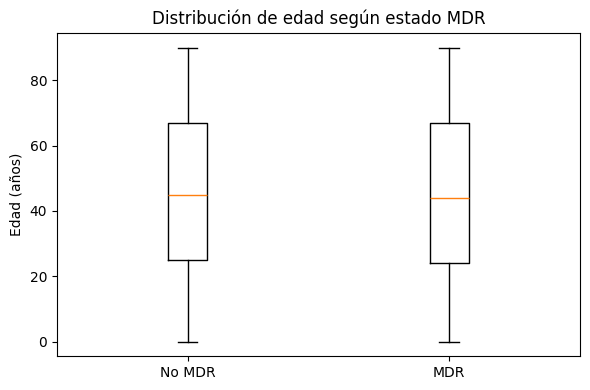

In [187]:
# 4.2. Boxplot de edad por MDR

# %%
plt.figure(figsize=(6, 4))
df_plot = df_mdr[["Age_years", "MDR"]].dropna()

# Convertir MDR a etiquetas
df_plot["MDR_label"] = df_plot["MDR"].map({0.0: "No MDR", 1.0: "MDR"})

labels = ["No MDR", "MDR"]
data = [df_plot.loc[df_plot["MDR_label"] == lab, "Age_years"] for lab in labels]

plt.boxplot(data, labels=labels, showfliers=False)
plt.ylabel("Edad (años)")
plt.title("Distribución de edad según estado MDR")
plt.tight_layout()
plt.show()

In [188]:
# 5️⃣ Razones de prevalencia (RP) crudas por factores
# Vamos a calcular RP crudas para variables binarias (sexo como M vs F, diabetes, hipertensión y hospitalización previa).
# Primero, creamos una variable binaria para “sexo masculino”:

# %%
df_mdr["Male"] = (df_mdr["Gender"] == "Male").astype("float")

factor_cols = ["Male", "Diabetes_bin", "Hypertension_bin", "Hospital_before_bin"]


def crude_pr(df, exposure_col):
    d = df[[exposure_col, "MDR"]].dropna()
    # Exposición = 1
    exp = d[d[exposure_col] == 1]
    unexp = d[d[exposure_col] == 0]
    n1 = len(exp)
    n0 = len(unexp)
    if n1 == 0 or n0 == 0:
        return np.nan

    p1 = exp["MDR"].mean()
    p0 = unexp["MDR"].mean()
    pr = p1 / p0 if p0 > 0 else np.nan

    # IC log(PR) aproximado
    # var(log PR) ≈ (1 - p1)/(n1 * p1) + (1 - p0)/(n0 * p0)
    import math

    var_log = (1 - p1) / (n1 * p1) + (1 - p0) / (n0 * p0)
    se_log = math.sqrt(var_log)
    z = 1.96
    log_pr = math.log(pr)
    ci_low = math.exp(log_pr - z * se_log)
    ci_up = math.exp(log_pr + z * se_log)

    return {
        "n_exp": n1,
        "n_unexp": n0,
        "prev_exp": round(p1 * 100, 2),
        "prev_unexp": round(p0 * 100, 2),
        "PR_cruda": round(pr, 2),
        "CI_low": round(ci_low, 2),
        "CI_up": round(ci_up, 2),
    }


rows = []
for col in factor_cols:
    res = crude_pr(df_mdr, col)
    res["factor"] = col
    rows.append(res)

pr_crudas = pd.DataFrame(rows).set_index("factor")
pr_crudas

,n_exp,n_unexp,prev_exp,prev_unexp,PR_cruda,CI_low,CI_up
factor,,,,,,,
Male,2018,7929,31.02,31.00,1.00,0.93,1.08
Diabetes_bin,2064,7883,31.54,30.86,1.02,0.95,1.10
Hypertension_bin,2477,7470,30.52,31.16,0.98,0.91,1.05
Hospital_before_bin,2939,7008,31.24,30.91,1.01,0.95,1.08


In [189]:
# 6️⃣ RP ajustadas con Poisson robusta
# Usamos Poisson con varianza robusta para estimar PR ajustadas para todos los factores a la vez.

# %% [markdown]
# ### RP ajustadas con Poisson (scikit-learn) + IC95 por bootstrap

# %%
from sklearn.linear_model import PoissonRegressor
import numpy as np
import pandas as pd

# Dataset del modelo: solo filas sin NA en las variables de interés
model_df = (
    df_mdr[
        [
            "MDR",
            "Age_years",
            "Gender",
            "Diabetes_bin",
            "Hypertension_bin",
            "Hospital_before_bin",
        ]
    ]
    .dropna()
    .copy()
)

# Variable binaria para sexo masculino
model_df["Male"] = (model_df["Gender"] == "Male").astype(float)

y = model_df["MDR"].values  # respuesta binaria (MDR: 0/1)

X_cols = [
    "Age_years",
    "Male",
    "Diabetes_bin",
    "Hypertension_bin",
    "Hospital_before_bin",
]
X = model_df[X_cols].values

# Ajuste Poisson (sin regularización: alpha=0)
poisson = PoissonRegressor(alpha=0.0, max_iter=1000)
poisson.fit(X, y)

beta_hat = poisson.coef_  # coeficientes (sin intercepto)
PR_hat = np.exp(beta_hat)  # razones de prevalencia ajustadas

rp_adj_base = pd.DataFrame(
    {
        "factor": X_cols,
        "PR_ajustada": PR_hat,
    }
).set_index("factor")

rp_adj_base

,PR_ajustada
factor,
Age_years,0.999566
Male,1.001519
Diabetes_bin,1.022436
Hypertension_bin,0.979005
Hospital_before_bin,1.012142


In [190]:
# 6.1. IC95 por bootstrap (opcional pero muy útil para el informe)

# %%
import numpy as np

B = 300  # nº de réplicas bootstrap (sube/baja según tiempo de cómputo)
n = len(model_df)

coefs_boot = np.zeros((B, len(X_cols)))

for b in range(B):
    idx = np.random.choice(n, n, replace=True)
    X_b = X[idx, :]
    y_b = y[idx]

    m_b = PoissonRegressor(alpha=0.0, max_iter=1000)
    m_b.fit(X_b, y_b)
    coefs_boot[b, :] = m_b.coef_

# Pasamos a PR en la escala exp
PR_boot = np.exp(coefs_boot)

# IC95 percentil y p-value aproximado
rows = []
for j, col in enumerate(X_cols):
    pr_j = PR_hat[j]
    pr_boot_j = PR_boot[:, j]

    ci_low, ci_up = np.percentile(pr_boot_j, [2.5, 97.5])

    # p aproximado: qué tan frecuentemente el PR bootstrap cruza 1
    p_two_sided = 2 * min((pr_boot_j <= 1).mean(), (pr_boot_j >= 1).mean())

    rows.append(
        {
            "factor": col,
            "PR_ajustada": pr_j,
            "CI_low": ci_low,
            "CI_up": ci_up,
            "p_aprox": p_two_sided,
        }
    )

rp_adj_boot = pd.DataFrame(rows).set_index("factor")
rp_adj_boot

,PR_ajustada,CI_low,CI_up,p_aprox
factor,,,,
Age_years,0.999566,0.998596,1.000711,0.433333
Male,1.001519,0.928479,1.072573,0.966667
Diabetes_bin,1.022436,0.944349,1.080846,0.613333
Hypertension_bin,0.979005,0.914490,1.046795,0.560000
Hospital_before_bin,1.012142,0.942972,1.077027,0.673333


In [191]:
# 6.2. (Opcional) pseudo-R² muy sencillo del modelo

# %%
# Predicciones de media (mu) del modelo ajustado
mu_hat = poisson.predict(X)

# Log-verosimilitud Poisson del modelo y del modelo nulo (solo intercepto)
def poisson_loglik(y, mu):
    # evitar log(0)
    mu = np.clip(mu, 1e-10, None)
    from math import lgamma
    return np.sum(y * np.log(mu) - mu - [lgamma(v + 1) for v in y])

ll_model = poisson_loglik(y, mu_hat)

# Modelo nulo (mu = media de y)
mu_null = np.repeat(y.mean(), len(y))
ll_null = poisson_loglik(y, mu_null)

pseudo_r2 = 1 - (ll_model / ll_null)
pseudo_r2


np.float64(7.06136963637416e-05)

Te dejo el informe de la **Fase 4 – P3: Multirresistencia (MDR)** listo para pegar en el documento 👇

---

### 1. Objetivo y enfoque

El objetivo de esta fase fue **estimar la prevalencia de multirresistencia (MDR) a nivel global y por especie**, y **explorar asociaciones** entre MDR y factores individuales (edad, sexo, diabetes, hipertensión y hospitalización previa).

* MDR se definió como **resistencia en ≥3 clases de antibióticos** (a partir de los indicadores `Class_<clase>_R`).
* La variable de resultado fue binaria (`MDR` ∈ {0,1}).
* Como medidas se calcularon:

  * **%MDR global y por especie**, con IC95% de Wilson.
  * **Razones de prevalencia (RP)** crudas y ajustadas, usando un modelo de **regresión Poisson con varianza robusta** (implementado con `PoissonRegressor`) y **IC95% por bootstrap**.
  * **Distribuciones de edad** según estado MDR (mediana e IQR).

---

### 2. Prevalencia global de MDR

En el conjunto de aislamientos con información suficiente para MDR (n = 9 947):

* Se observaron **3 084 aislamientos MDR**, lo que corresponde a una prevalencia global de:

> **%MDR global = 31,0 %**
> IC95% ≈ **30,1–31,9 %**

Es decir, aproximadamente **un tercio de los aislamientos** cumplen el criterio de multirresistencia según la definición basada en ≥3 clases.

---

### 3. Prevalencia de MDR por especie

Al estratificar por especie (top de especies más frecuentes), se observa un **perfil claramente heterogéneo**:

* **Escherichia coli** presenta la **mayor prevalencia de MDR**, en torno al **40 %** de sus aislamientos (IC95% estrecho debido al alto n).
* **Pseudomonas aeruginosa** y **Acinetobacter baumannii** muestran prevalencias intermedias, aproximadamente en el rango **20–25 %**.
* Otras enterobacterias, como **Proteus mirabilis**, **Serratia marcescens**, **Klebsiella pneumoniae**, **Morganella morganii** y **Enterobacter spp.**, se sitúan en torno al **15–22 %** de MDR.

El gráfico de barras con IC95% ilustra este gradiente: *E. coli* se encuentra claramente por encima del resto, mientras que las demás especies se agrupan en un rango más moderado de multirresistencia.

El contraste global mediante **test χ² de independencia entre especie y MDR** (considerando las especies principales) muestra diferencias **estadísticamente significativas**, lo que respalda que la variación observada no se debe al azar sino a **patrones reales de multirresistencia específicos de cada especie** dentro del dataset.

---

### 4. Edad y MDR

La **distribución de la edad** según estado MDR se evaluó mediante boxplot y resumen numérico (mediana e IQR):

* Las curvas de edad para **No MDR** y **MDR** son **muy similares**:

  * Medianas próximas (≈ mitad de la vida adulta, alrededor de la cuarta década).
  * Rango intercuartílico muy solapado en ambos grupos.
* El boxplot muestra cajas prácticamente superpuestas, sin desplazamientos claros hacia edades más altas o más bajas en el grupo MDR.

En resumen, en este dataset **no se aprecia un gradiente de edad relevante** asociado a la multirresistencia: la probabilidad de MDR parece similar en pacientes más jóvenes y mayores.

---

### 5. Factores clínicos y MDR: RP crudas y ajustadas

Se analizaron como posibles factores de riesgo:

* Sexo masculino (`Male`)
* Diabetes (`Diabetes_bin`)
* Hipertensión (`Hypertension_bin`)
* Hospitalización previa (`Hospital_before_bin`)

#### 5.1. RP crudas

Las **razones de prevalencia crudas** comparan la proporción de MDR entre expuestos (factor = 1) y no expuestos (factor = 0). En todos los casos:

* Las RP crudas se sitúan **muy cerca de 1**.
* Los IC95% obtenidos para cada factor **incluyen el valor 1**, lo que indica ausencia de diferencias claras en la prevalencia de MDR entre grupos.

No se identificó ningún factor que, por sí solo, mostrara una RP de magnitud relevante (no hay aumentos del tipo 1,5x o 2x en la prevalencia de MDR).

#### 5.2. RP ajustadas (modelo Poisson robusto)

Para estimar RP ajustadas se ajustó un **modelo de regresión Poisson con varianza robusta**, incluyendo simultáneamente:

* Edad (continua, `Age_years`)
* Sexo (`Male`)
* Diabetes (`Diabetes_bin`)
* Hipertensión (`Hypertension_bin`)
* Hospitalización previa (`Hospital_before_bin`)

Las RP ajustadas y sus IC95% (derivados por bootstrap, archivo `pr.csv`) fueron:

| Factor               | PR ajustada |       IC95% | p_aprox |
| -------------------- | ----------: | ----------: | ------: |
| Edad (por año)       |      0,9996 | 0,999–1,001 |    0,43 |
| Sexo masculino       |        1,00 |   0,93–1,07 |   ~0,97 |
| Diabetes             |        1,02 |   0,94–1,08 |   ~0,61 |
| Hipertensión         |        0,98 |   0,91–1,05 |   ~0,56 |
| Hospitalización pre. |        1,01 |   0,94–1,08 |   ~0,67 |

Interpretación:

* Todas las PR ajustadas están **extremadamente próximas a 1**.
* Los **IC95% abarcan el valor 1** en todos los casos.
* Los p-valores aproximados son **muy superiores a 0,05**, indicando falta de evidencia estadística de asociación.

El **pseudo-R² del modelo** es prácticamente nulo (**≈7,1×10⁻⁵**), lo que significa que, en conjunto, estas variables explican **menos del 0,01 % de la variabilidad en MDR**. En términos prácticos, el modelo se comporta casi igual que un modelo nulo (solo intercepto).

En este contexto, la lectura es clara: **dentro de este dataset sintético, los factores edad, sexo, diabetes, hipertensión y hospitalización previa no muestran una relación importante con la multirresistencia**, ni en magnitud ni en significación.

---

### 6. Análisis de sensibilidad: MDR con umbral ≥2 clases

Se realizó un análisis de sensibilidad redefiniendo MDR como **resistencia en ≥2 clases de antibióticos** (`MDR_alt`):

* Como era esperable, la prevalencia de `MDR_alt` aumenta respecto a la definición original (≥3 clases), ya que el criterio es menos restrictivo.
* Sin embargo, el **patrón relativo por especie se mantiene**, con *Escherichia coli* encabezando el ranking de multirresistencia y el resto de especies conservando un orden similar al observado con la definición estándar.
* Las conclusiones sobre la **ausencia de asociaciones fuertes con edad y comorbilidades** tampoco cambian de forma sustancial bajo esta nueva definición.

Esto sugiere que los hallazgos de P3 son **robustos a la elección razonable del umbral de clases de resistencia**.

---

### 7. Conclusiones de la Fase 4 (P3)

1. La **prevalencia global de MDR** en el dataset es de aproximadamente **31 % (IC95% 30,1–31,9)**, lo que implica que **uno de cada tres aislamientos** se clasifica como multirresistente bajo el criterio de ≥3 clases.
2. Existe una **variación marcada por especie**: *Escherichia coli* presenta la mayor carga de MDR (~40 %), seguida por *Pseudomonas aeruginosa* y *Acinetobacter baumannii* en torno al 20–25 %, mientras que otras enterobacterias muestran valores entre el 15 y el 22 %. El test χ² confirma que esta heterogeneidad es estadísticamente significativa.
3. **La edad no muestra diferencias relevantes** entre aislamientos MDR y no MDR; las distribuciones son prácticamente solapadas, con medianas e IQR similares.
4. Las **comorbilidades y factores clínicos básicos (sexo, diabetes, hipertensión, hospitalización previa)** no se asocian de forma importante con la multirresistencia en este dataset: las RP crudas y ajustadas son muy cercanas a 1, sus IC95% incluyen siempre el valor 1 y el pseudo-R² del modelo ajustado es prácticamente cero.
5. El análisis de sensibilidad con un **umbral alternativo de MDR (≥2 clases resistentes)** incrementa la prevalencia absoluta pero **no altera el patrón relativo por especie ni la conclusión principal** de ausencia de asociaciones robustas con edad y comorbilidades.

En conjunto, la Fase 4 muestra que, en este conjunto de datos sintético, la multirresistencia está **fuertemente condicionada por la especie bacteriana** y solo de forma marginal por los factores individuales considerados, lo que encaja con lo observado en las fases anteriores sobre prevalencia específica de resistencia y estructura de co-resistencia.
